## packages

In [50]:
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import warnings
from dateutil.relativedelta import relativedelta
from dateutil import parser
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

## data prep

In [52]:
# Function call to process the tradewed data file
def data_preprocess(filepath):
    rawdata = pd.read_csv(filepath)
    rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0] # Ignore trade stamps with zero volume
    # Remove BILLs , STRIPs and TRSY FRN data to skip the computation from yield to price for Bills and negative spreads for Strips + Treasury FRN
    substring = 'Bill'
    substring2 = 'Strip'
    substring3 = 'TRSY FRN'
    filter = rawdata['MATURITY_RANGE'].str.contains(substring)
    rawdata = rawdata[~filter]
    filter2 = rawdata['MATURITY_RANGE'].str.contains(substring2)
    rawdata = rawdata[~filter2]
    filter3 = rawdata['MATURITY_RANGE'].str.contains(substring3)
    rawdata = rawdata[~filter3]
    rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT'] # Only consider outright trades
    rawdata.reset_index(inplace=True)
    # Convert TRADETIME , MATURITY DATE and TRADE DATE to datetime and assign new index
    tradetime = []
    tradedate = []
    maturitydate = []
    for i in range(rawdata.shape[0]):
        tradetime.append(datetime.datetime.strptime(rawdata['TRADETIME'].iloc[i].rstrip(' Z'), "%Y-%m-%d %H:%M:%S.%f"))
        tradedate.append(datetime.datetime.strptime(rawdata['TRADEDATE'].iloc[i], '%m/%d/%y'))
        maturitydate.append(datetime.datetime.strptime(rawdata['MATURITY_DATE'].iloc[i], '%m/%d/%y'))
    rawdata['TIMESTAMP'] = tradetime
    rawdata['TRADEDATE'] = tradedate
    rawdata['MATURITY_DATE'] = maturitydate
    rawdata.set_index('TIMESTAMP', inplace= True)
    rawdata.sort_index(inplace=True)
    return rawdata

In [53]:
tw1 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 1.csv')
tw2 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 2.csv')
tw3 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 3.csv')
tw4 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 4.csv')
rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)

In [54]:
rawdata.columns

Index(['index', 'TRADEDATE', 'DEALER', 'DEALERCOUNT', 'ACCEPTED',
       'SEEN_INQUIRY', 'ACCEPTEDVOL', 'SEENVOLUME', 'PRICE', 'TRADETIME',
       'INSTRUMENT', 'INSTRUMENT_DESC', 'MATURITY_DATE', 'MATURITY_RANGE',
       'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'PROTOCOL', 'TRADETYPE',
       'SOURCE'],
      dtype='object')

In [55]:
rawdata.head(5)

,index,TRADEDATE,DEALER,DEALERCOUNT,ACCEPTED,SEEN_INQUIRY,ACCEPTEDVOL,SEENVOLUME,PRICE,TRADETIME,...,INSTRUMENT_DESC,MATURITY_DATE,MATURITY_RANGE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,PROTOCOL,TRADETYPE,SOURCE
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,47059,2023-10-02,D69,5,1,1,1100.90,1100.90,99.761887,2023-10-02 06:47:43.000 Z,...,"T 4 5/8 <MD2Y,2462045> 5yr",2028-09-30,Note 3.5 - 5.5 Year,4.625,BUY,99.769531,99.753906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,19829,2023-10-02,D38,5,1,1,3939.00,3939.00,99.691574,2023-10-02 06:47:43.000 Z,...,"T 5 <MD2Y,2460919>",2025-08-31,Note 1.5 - 3.5 Year,5.000,BUY,99.703125,99.691406,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,50786,2023-10-02,D28,5,1,1,297.95,297.95,89.461106,2023-10-02 06:47:43.000 Z,...,"T 1 1/8 <MD2Y,2461345>",2026-10-31,Note 1.5 - 3.5 Year,1.125,BUY,89.488281,89.433594,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,24582,2023-10-02,D38,5,1,1,676.70,676.70,90.133013,2023-10-02 06:47:43.000 Z,...,"T 4 1/8 <MD2Y,2471130> 30yr",2053-08-15,Note >10 Year,4.125,BUY,90.160156,90.128906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,57986,2023-10-02,D11,5,1,1,176.75,176.75,60.906450,2023-10-02 06:47:43.000 Z,...,"T 2 1/4 <MD2Y,2470583>",2052-02-15,Note >10 Year,2.250,BUY,60.960938,60.882812,REG List,OUTRIGHT,TW


In [56]:
filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()
filtered_rawdata.head()

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID
TIMESTAMP,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812


In [57]:
filtered_rawdata.shape

(50741, 11)

In [58]:
filtered_rawdata['SIGN'] = filtered_rawdata['SIDE'].apply(lambda x: 1 if x == 'BUY' else -1)
filtered_rawdata['ACCEPTEDVOL'] = filtered_rawdata['ACCEPTEDVOL'] * 10
filtered_rawdata['SIGNED_VOLUME'] = filtered_rawdata['ACCEPTEDVOL'] * filtered_rawdata['SIGN']
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME
TIMESTAMP,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0


In [59]:
# Calculate years to maturity
ytm = []
for i in range(0,rawdata.shape[0]):
    ytm.append(relativedelta(filtered_rawdata['MATURITY_DATE'].iloc[i],filtered_rawdata['TRADEDATE'].iloc[i]).years)
filtered_rawdata['Years to Maturity'] = ytm
# calculate spreads
filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/2

In [60]:
filtered_rawdata['MATURITY_RANGE'].unique()

array(['Note 3.5 - 5.5 Year', 'Note 1.5 - 3.5 Year', 'Note >10 Year',
       'Note 5.5 - 10 Year', 'Note 0 - 1.5 Year', 'TIPS 0 - 5 year',
       'TIPS 5 - 10 year', 'TIPS > 10 year'], dtype=object)

In [61]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


## Parameter for Price Impact Model: daily_vol, adv, beta

In [63]:
filtered_rawdata.MATURITY_RANGE.value_counts()

Note 1.5 - 3.5 Year    12244
Note 0 - 1.5 Year       9955
Note >10 Year           8946
Note 5.5 - 10 Year      8760
Note 3.5 - 5.5 Year     7661
TIPS 0 - 5 year         1620
TIPS > 10 year           782
TIPS 5 - 10 year         773
Name: MATURITY_RANGE, dtype: int64

## select one maturity data

In [65]:
# List of maturity ranges to filter
note_maturity_ranges = ['Note 1.5 - 3.5 Year', 'Note 0 - 1.5 Year', 'Note >10 Year',
                        'Note 5.5 - 10 Year', 'Note 3.5 - 5.5 Year']

# Filter data for the specified maturity ranges
group1 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'].isin(note_maturity_ranges)]


group1

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


In [66]:
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group1.groupby('TRADEDATE')['PRICE'].std()

# Map the daily volatility back to the original DataFrame
group1['Daily_Volatility'] = group1['TRADEDATE'].map(daily_volatility)

## daily volatility

In [68]:
group1.Daily_Volatility

TIMESTAMP
2023-10-02 06:47:43    12.553247
2023-10-02 06:47:43    12.553247
2023-10-02 06:47:43    12.553247
2023-10-02 06:47:43    12.553247
2023-10-02 06:47:43    12.553247
                         ...    
2023-12-29 13:51:46     9.042891
2023-12-29 13:51:46     9.042891
2023-12-29 13:51:46     9.042891
2023-12-29 13:51:46     9.042891
2023-12-29 13:51:46     9.042891
Name: Daily_Volatility, Length: 47566, dtype: float64

## ADV: average daily volume

In [70]:
def calculate_monthly_adv_separately(data):
    # resample volume to daily
    daily_vol = data['ACCEPTEDVOL'].resample('D').sum()
    print("Daily Total Volume:\n", daily_vol.head(10))

    october_total_vol = daily_vol[0]  # total volume for October
    december_total_vol = daily_vol[2]  # total volume for December
    # Calculate the number of trading days for October and December
    october_trading_days = data['ACCEPTEDVOL']['2023-10'].count()
    december_trading_days = data['ACCEPTEDVOL']['2023-12'].count()

    # Calculate ADV
    october_adv = october_total_vol / october_trading_days
    december_adv = december_total_vol / december_trading_days

    # Assign the ADV value
    data.loc['2023-10', 'ADV'] = october_adv
    data.loc['2023-12', 'ADV'] = december_adv

    # Forward fill for consistency
    data['ADV'].fillna(method='ffill', inplace=True)
    data['ADV'].fillna(method='bfill', inplace=True)

    return data[['ADV']], october_total_vol, december_total_vol

In [71]:
group1[['ADV']], october_total_vol, december_total_vol = calculate_monthly_adv_separately(group1)

Daily Total Volume:
 TIMESTAMP
2023-10-02    14129669.72
2023-10-03    12331141.51
2023-10-04    10819414.92
2023-10-05     8190788.92
2023-10-06     6369606.41
2023-10-07           0.00
2023-10-08           0.00
2023-10-09           0.00
2023-10-10    13034806.49
2023-10-11    11529757.01
Freq: D, Name: ACCEPTEDVOL, dtype: float64


In [72]:
group1.ADV

TIMESTAMP
2023-10-02 06:47:43    602.570247
2023-10-02 06:47:43    602.570247
2023-10-02 06:47:43    602.570247
2023-10-02 06:47:43    602.570247
2023-10-02 06:47:43    602.570247
                          ...    
2023-12-29 13:51:46    448.621923
2023-12-29 13:51:46    448.621923
2023-12-29 13:51:46    448.621923
2023-12-29 13:51:46    448.621923
2023-12-29 13:51:46    448.621923
Name: ADV, Length: 47566, dtype: float64

In [73]:
print('OCT',october_total_vol)
print('DEC',december_total_vol)

OCT 14129669.72
DEC 10819414.92


In [74]:
import math
beta = math.log(2)/1 # half-life is 30min, bin is 60 min
print('beta:',beta)

beta: 0.6931471805599453


## qt: quanity/volume in each bin (set bin 60min here)

In [76]:
def add_resampled_volume(df):
    result_df = df.copy()
    bin = result_df.index.floor('60T')
    # Calculate qt for each 60-minute window
    qt = (result_df.groupby(bin)['SIGNED_VOLUME']
                .transform('sum'))
    result_df['qt'] = qt

    return result_df

In [77]:
group1['SIGN'].unique()

array([ 1, -1])

In [78]:
group1 = add_resampled_volume(group1)
qt = group1['SIGNED_VOLUME'].resample('60T').sum()

# Compare results
print(group1[['SIGNED_VOLUME', 'qt']])
print(qt)

                     SIGNED_VOLUME           qt
TIMESTAMP                                      
2023-10-02 06:47:43        11009.0    -24017.80
2023-10-02 06:47:43        39390.0    -24017.80
2023-10-02 06:47:43         2979.5    -24017.80
2023-10-02 06:47:43         6767.0    -24017.80
2023-10-02 06:47:43         1767.5    -24017.80
...                            ...          ...
2023-12-29 13:51:46      -202000.0  13923146.94
2023-12-29 13:51:46       121200.0  13923146.94
2023-12-29 13:51:46      -252500.0  13923146.94
2023-12-29 13:51:46      -202000.0  13923146.94
2023-12-29 13:51:46        -2020.0  13923146.94

[47566 rows x 2 columns]
TIMESTAMP
2023-10-02 06:00:00      -24017.80
2023-10-02 07:00:00      -52704.83
2023-10-02 08:00:00      141046.50
2023-10-02 09:00:00     -442632.50
2023-10-02 10:00:00      117030.72
                          ...     
2023-12-29 09:00:00      259342.75
2023-12-29 10:00:00     6066299.37
2023-12-29 11:00:00   -16554973.63
2023-12-29 12:00:00     4

In [79]:
(group1.qt == 0).value_counts()

False    47566
Name: qt, dtype: int64

In [80]:
# Function to calculate I_t and v_t using the given equations from book
def calculate_impact_and_liquidity(data, beta, delta_t, lambda_value):
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    data['RETURN'] = data['PRICE'].pct_change()
    data['F_t_diff'] = data['SIGNED_VOLUME'].diff()
    data.dropna(inplace=True)

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma_value = data['Daily_Volatility'].iloc[i]
        qt = data['qt'].iloc[i]
        adv_value = data['ADV'].iloc[i]
        # Calculate v_t+delta_t using the exponential moving sum of volume
        v_values[i] = v_values[i-1] + (-beta * v_values[i-1] * delta_t + abs(qt))

        # Calculate I_t+delta_t using the impact equation
        if adv_value != 0:
            I_values[i] = I_values[i-1] + (-beta * I_values[i-1] * delta_t +
                                           lambda_value * sigma_value * (qt / np.sqrt(adv_value*v_values[i])))

    # Append the calculated values to the DataFrame for further analysis
    data['I_t'] = I_values
    data['v_t'] = v_values

    # Include PRICE in the returned DataFrame to calculate Delta_P in the next function
    return data

### func to find lambda
Lambda is the hyperparameter of the OW model, we should select lambda with the highest R2

In [82]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

def calculate_impact_and_liquidity(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data, beta

def estimate_lambda(data, initial_lambda, h_minutes, delta_t=1/24):
    """
    Estimate optimal lambda for a given time interval h_minutes
    h_minutes: horizon for returns (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    # Calculate impact states
    impact_data, beta = calculate_impact_and_liquidity(data, h_minutes, delta_t)

    # Calculate returns using h periods
    h_periods = int(len(impact_data) * (h_minutes/(24*60)))  # Convert minutes to fraction of day
    h_periods = max(1, h_periods)  # Ensure at least 1 period

    # Calculate Δ^h P = (P_{t+h} - P_t)/P_t using h as the horizon
    impact_data['Delta_h_P'] = (impact_data['PRICE'].shift(-h_periods) - impact_data['PRICE']) / impact_data['PRICE']

    # Calculate Δ^h I = I_{t+h} - I_t using h as the horizon
    impact_data['Delta_h_I'] = impact_data['I_t'].shift(-h_periods) - impact_data['I_t']

    # Remove NaN values
    impact_data.dropna(inplace=True)

    # Run regression: Δ^h P = Δ^h I(λ) + ϵ
    X = impact_data[['Delta_h_I']]
    y = impact_data['Delta_h_P']

    model = LinearRegression()
    model.fit(X, y)

    optimal_lambda = model.coef_[0]
    r_squared = model.score(X, y)

    return optimal_lambda, r_squared, beta, impact_data

def grid_search_lambda(data, h_values_minutes, delta_t=1/24):
    """
    Test different time intervals to find optimal lambda
    """
    results = []
    for h_minutes in h_values_minutes:
        optimal_lambda, r_squared, beta, _ = estimate_lambda(data, 1.0, h_minutes, delta_t)
        results.append({
            'h_minutes': h_minutes,
            'h_hours': h_minutes/60,
            'h_periods': max(1, int(len(data) * (h_minutes/(24*60)))),
            'beta': beta,
            'lambda': optimal_lambda,
            'r_squared': r_squared
        })
    return results

In [83]:
h_values_minutes = [6, 12, 18, 24, 30, 48, 60, 90, 120]  # horizons in minutes
delta_t = 1/24  # 1 hour for impact decay
results = grid_search_lambda(group1, h_values_minutes, delta_t)

def print_results(results):
    print("\nSummary of Results:")
    print("-" * 80)
    print(f"{'h (min)':>10} {'beta':>12} {'lambda':>12} {'R²':>12}")
    print("-" * 80)

    for result in results:
        h_min = result['h_minutes']
        beta = result['beta']
        lambda_val = result['lambda']
        r2 = result['r_squared']

        print(f"{h_min:10.1f} {beta:12.6f} {lambda_val:12.6f} {r2:12.6f}")
    print("-" * 80)

# After running grid_search_lambda, use:
results = grid_search_lambda(group1, h_values_minutes, delta_t)
print_results(results)


Summary of Results:
--------------------------------------------------------------------------------
   h (min)         beta       lambda           R²
--------------------------------------------------------------------------------
       6.0     6.931472    -0.000018     0.000212
      12.0     3.465736    -0.000016     0.000553
      18.0     2.310491    -0.000012     0.000675
      24.0     1.732868    -0.000007     0.000387
      30.0     1.386294    -0.000012     0.001677
      48.0     0.866434    -0.000003     0.000247
      60.0     0.693147    -0.000004     0.000685
      90.0     0.462098    -0.000004     0.001291
     120.0     0.346574    -0.000001     0.000040
--------------------------------------------------------------------------------


set $\lambda = 0.000002$, since the R2 is the largest here

Then fill the result back to calculate the price impact (I_t) at each state

In [85]:
def ow(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values/10
    data['v_t'] = v_values
    return data

In [86]:
df_it = ow(group1, h_minutes=30.0, delta_t=1/24)

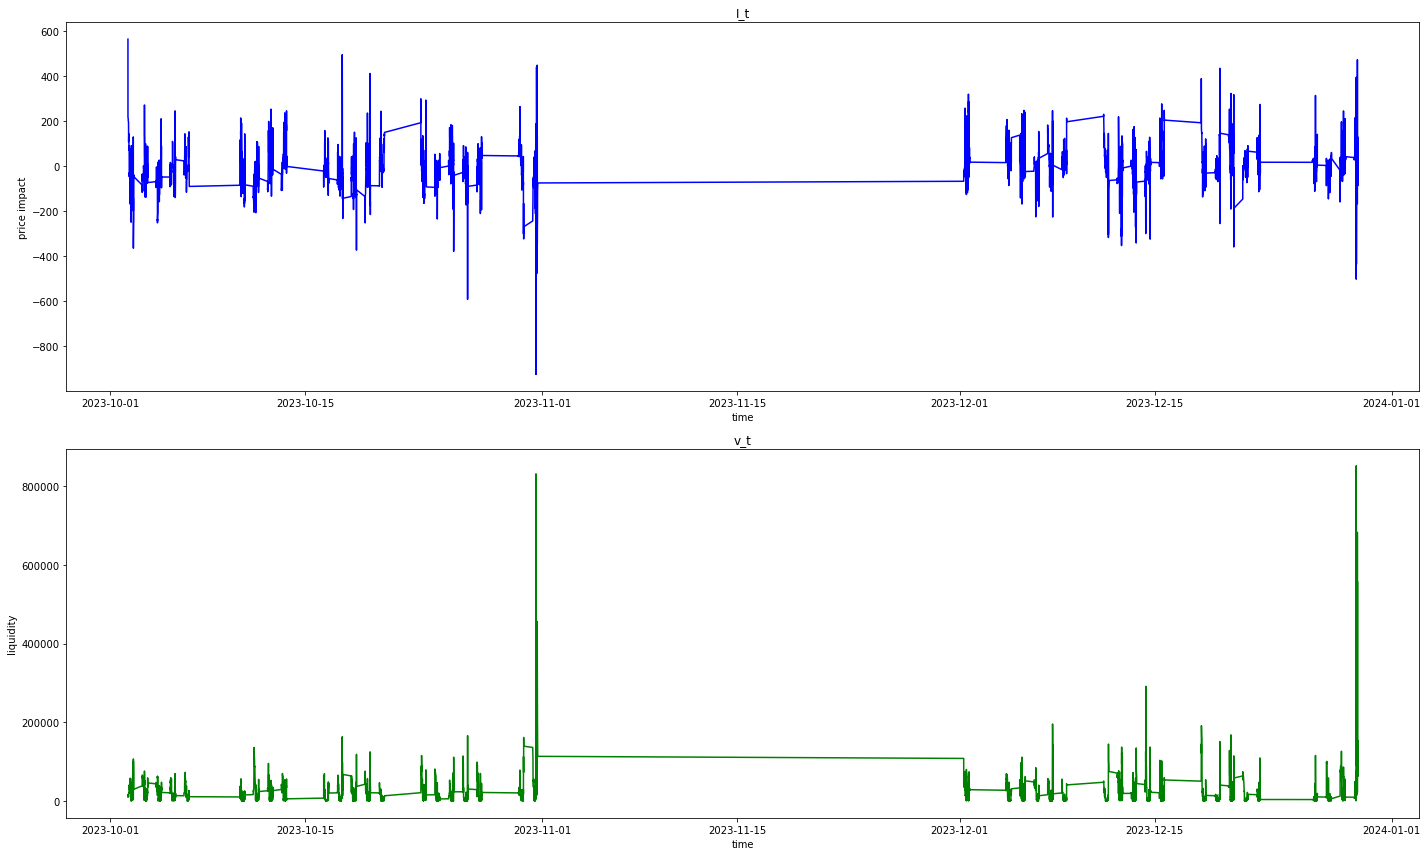

In [87]:
plt.figure(figsize=(20, 12))

# First subplot for df_it.I_t
plt.subplot(2, 1, 1)
plt.plot(df_it.I_t, color='blue')
plt.xlabel('time')
plt.ylabel('price impact')
plt.title('I_t')

# Second subplot for df_it.v_t
plt.subplot(2, 1, 2)
plt.plot(df_it.v_t, color='green')
plt.xlabel('time')
plt.ylabel('liquidity')
plt.title('v_t')

plt.tight_layout()
plt.show()


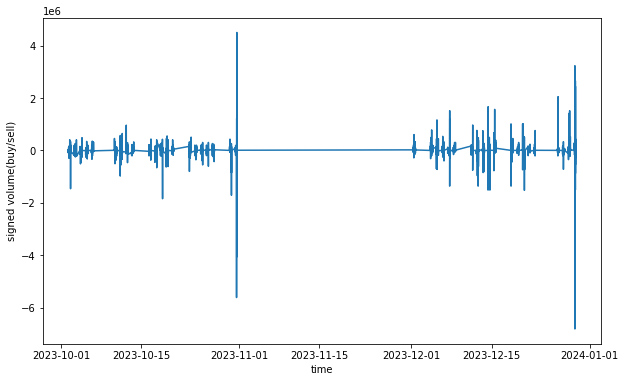

In [88]:
plt.figure(figsize=(10,6))
plt.plot(df_it.SIGNED_VOLUME)
plt.xlabel('time')
plt.ylabel('signed volume(buy/sell)')
plt.show()

# Find the optimal volume

In [90]:
import numpy as np
import math

def ow_with_optimal_volume(data, h_minutes, delta_t=1/24, target_impact=40):
    """
    Calculate impact state I_t, market activity v_t, and optimal trading volume Q_t.

    h_minutes: Time interval for return horizon (in minutes)
    delta_t: Time step for impact decay (in hours)
    target_impact: Desired target impact level (e.g., 40 bps)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t), liquidity (v_t), and optimal volume (Q_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))
    optimal_Q_values = np.full(len(data), np.nan)  # Placeholder for optimal trading volume

    # Initial values for I_t and v_t
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects

            # Calculate optimal Q_t based on the target impact
            Q_t = (target_impact - I_values[i] * (1 - beta * delta_t)) * np.sqrt(adv * v_values[i]) / sigma
            optimal_Q_values[i] = Q_t
        else:
            I_values[i] = I_values[i-1]  # Carry forward the previous impact state if ADV or v_t is zero

    # Assign calculated arrays back to the DataFrame
    data['I_t'] = I_values
    data['v_t'] = v_values
    data['Optimal_Q_t'] = abs(optimal_Q_values)

    return data

In [91]:
df_it = ow_with_optimal_volume(group1, h_minutes=30, delta_t=1/24)

In [92]:
df_it

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,SIGNED_VOLUME,Years to Maturity,Spread,Daily_Volatility,ADV,qt,ABS_VOLUME,I_t,v_t,Optimal_Q_t
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,...,11009.0,4,0.007812,12.553247,602.570247,-24017.80,11009.0,5629.892547,11009.000000,NaN
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,...,39390.0,1,0.005859,12.553247,602.570247,-24017.80,39390.0,5484.137568,12601.903132,1.125537e+06
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,...,2979.5,3,0.027344,12.553247,602.570247,-24017.80,2979.5,5181.234950,12061.839142,1.039861e+06
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,...,6767.0,29,0.015625,12.553247,602.570247,-24017.80,6767.0,4913.860078,11764.662656,9.735371e+05
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,...,1767.5,28,0.039062,12.553247,602.570247,-24017.80,1767.5,4638.563911,11203.565031,8.963486e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,...,-202000.0,0,0.027344,9.042891,448.621923,13923146.94,202000.0,726.076405,104193.504075,4.870026e+05
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,...,121200.0,4,0.046875,9.042891,448.621923,13923146.94,121200.0,843.713166,105148.005348,5.734136e+05
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,...,-252500.0,1,0.031250,9.042891,448.621923,13923146.94,252500.0,474.877416,113418.237325,3.214001e+05


In [93]:
# Calculate Slippage
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID'])/row['MID'] * 10000 # Buy side slippage in bps
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE'])/row['MID'] * 10000 # Sell side slippage in bps
    return None

def calculate_slippage_dollars(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) # Buy side slippage in $
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) # Sell side slippage in $
    return None

group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Slippage_dollars'] = group1.apply(calculate_slippage_dollars, axis=1)

# Trading Overview

In [95]:
import pandas as pd

# Ensure that TRADEDATE is in datetime format
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Filter for October data and calculate total slippage cost in dollars
october_data = group1[group1['TRADEDATE'].dt.month == 10]
total_slippage_cost_oct = (october_data['Slippage_dollars'] * october_data['ACCEPTEDVOL']).sum()

# Filter for December data and calculate total slippage cost in dollars
december_data = group1[group1['TRADEDATE'].dt.month == 12]
total_slippage_cost_dec = (december_data['Slippage_dollars'] * december_data['ACCEPTEDVOL']).sum()

# Display the results
print(f"Total Slippage Cost in Dollars for October: ${total_slippage_cost_oct:,.2f}")
print(f"Total Slippage Cost in Dollars for December: ${total_slippage_cost_dec:,.2f}")

Total Slippage Cost in Dollars for October: $2,241,604.13
Total Slippage Cost in Dollars for December: $-5,724,009.44


In [96]:
group1.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Daily_Volatility', 'ADV', 'qt', 'MID', 'Slippage_bps',
       'Slippage_dollars'],
      dtype='object')

In [97]:
# total accepted volume
total_accept_vol = group1['ACCEPTEDVOL'].sum()

In [98]:
# num of trades
num_of_trades = group1.count()[0]
num_of_trades

47566

In [99]:
# dealer count
dealer_count = len(group1['DEALER'].unique())

In [100]:
# notional value
notional = 100 * total_accept_vol
notional

77221848760.0

In [101]:
# weighted avg slippage
group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

volume_weighted_slippage = group1['Weighted_Slippage'].sum() / (group1['ACCEPTEDVOL'].sum())

volume_weighted_slippage

0.10943155145373573

In [102]:
# price impact
avg_price_impact = df_it['I_t'].mean()
avg_price_impact

45.07604040119363

In [103]:
import pandas as pd

# Define maturity ranges to filter and analyze
note_maturity_ranges = ['Note 1.5 - 3.5 Year', 'Note 0 - 1.5 Year',
                        'Note >10 Year', 'Note 5.5 - 10 Year', 'Note 3.5 - 5.5 Year']

# Initialize an empty list to store overview data for each maturity and month
overview_data = []

# Loop through each maturity range and each month (October and December)
for maturity in note_maturity_ranges:
    # Filter the main data (filtered_rawdata) for each maturity range
    group = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == maturity]

    # Convert TRADEDATE to datetime if not already
    group['TRADEDATE'] = pd.to_datetime(group['TRADEDATE'])

    for month in [10, 12]:  # October and December
        # Filter by the specific month in the main data
        group_month = group[group['TRADEDATE'].dt.month == month]

        if group_month.empty:
            # Skip if there’s no data for this maturity range and month
            continue

        # Calculate metrics
        total_accept_vol = group_month['ACCEPTEDVOL'].sum()
        num_of_trades = len(group_month)
        dealer_count = group_month['DEALER'].nunique()
        notional = 100 * total_accept_vol  # Notional value as 100 times the accepted volume

        # Calculate volume-weighted slippage
        group_month['MID'] = (group_month['COMP_ASK'] + group_month['COMP_BID']) / 2
        group_month['Slippage_bps'] = group_month.apply(calculate_slippage, axis=1)
        group_month['Weighted_Slippage'] = group_month['Slippage_bps'] * group_month['ACCEPTEDVOL']

        volume_weighted_slippage = group_month['Weighted_Slippage'].sum() / total_accept_vol if total_accept_vol > 0 else 0

        # Calculate average price impact from df_it based on maturity range and month
        df_it_maturity_month = df_it[(df_it['MATURITY_RANGE'] == maturity) &
                                     (df_it['TRADEDATE'].dt.month == month)]

        avg_price_impact = df_it_maturity_month['I_t'].mean() if 'I_t' in df_it_maturity_month else 0

        # Check if avg_price_impact is NaN, and handle accordingly
        if pd.isna(avg_price_impact):
            avg_price_impact = 0  # Set to 0 if there are no valid values

        # Store the calculated metrics in the overview data list
        overview_data.append({
            'Maturity Range': maturity,
            'Month': 'October' if month == 10 else 'December',
            'Notional Value': notional,
            'Num of Trades': num_of_trades,
            'Total Accepted Volume': total_accept_vol,
            'Volume Weighted Slippage': volume_weighted_slippage,
            'Avg Price Impact': abs(avg_price_impact),
            'Dealer Count': dealer_count
        })

# Convert the overview data list to a DataFrame
overview_df = pd.DataFrame(overview_data)

# Separate October and December for display
overview_oct = overview_df[overview_df['Month'] == 'October']
overview_dec = overview_df[overview_df['Month'] == 'December']


In [104]:
overview_oct[['Maturity Range',  'Notional Value', 'Num of Trades',
       'Total Accepted Volume', 'Volume Weighted Slippage', 'Avg Price Impact',
       'Dealer Count']]

,Maturity Range,Notional Value,Num of Trades,Total Accepted Volume,Volume Weighted Slippage,Avg Price Impact,Dealer Count
0,Note 1.5 - 3.5 Year,8.824201e+09,5337,88242014.31,0.088455,1.328361,24
2,Note 0 - 1.5 Year,8.735803e+09,4972,87358029.99,0.273529,3.595182,23
4,Note >10 Year,7.019864e+09,4696,70198641.05,3.925085,159.518247,24
6,Note 5.5 - 10 Year,7.317549e+09,4545,73175493.84,-0.083820,21.189705,24
8,Note 3.5 - 5.5 Year,7.663586e+09,3899,76635860.90,0.512063,8.105183,24


In [105]:
overview_dec[['Maturity Range',  'Notional Value', 'Num of Trades',
       'Total Accepted Volume', 'Volume Weighted Slippage', 'Avg Price Impact',
       'Dealer Count']]

,Maturity Range,Notional Value,Num of Trades,Total Accepted Volume,Volume Weighted Slippage,Avg Price Impact,Dealer Count
1,Note 1.5 - 3.5 Year,1.055202e+10,6907,1.055202e+08,0.168188,62.445700,25
3,Note 0 - 1.5 Year,7.829091e+09,4983,7.829091e+07,-8.728555,45.170258,20
5,Note >10 Year,5.931674e+09,4250,5.931674e+07,1.135837,66.880657,23
7,Note 5.5 - 10 Year,7.391046e+09,4215,7.391046e+07,4.684995,65.572531,25
9,Note 3.5 - 5.5 Year,5.957014e+09,3762,5.957014e+07,-0.064879,67.371949,23


# Total Transaction cost

In [107]:
group1['Total_Cost'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']

total_cost = group1['Total_Cost'].sum()

print("Total Transaction Cost($):", total_cost)

Total Transaction Cost($): -3482405.3187634377


# Separate the Oct and Dec

In [109]:
group1_oct_dec = group1[(group1.index.month == 10) | (group1.index.month == 12)]

# Define the time session intra day

In [111]:
def assign_time_session(timestamp):
    hour = timestamp.hour
    if 7 <= hour < 9 or (hour == 9 and timestamp.minute < 30):
        return "Pre-market"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 14:
        return "Mid-day"
    elif 14 <= hour < 16:
        return "Afternoon"
    else:
        return "Post-market"

group1_oct_dec['Time_Session'] = group1_oct_dec.index.map(assign_time_session)

In [112]:
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Slippage_dollars'] = group1.apply(calculate_slippage_dollars, axis=1)
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100
# Filter data separately for October and December
group1_oct = group1[group1.index.month == 10]
group1_dec = group1[group1.index.month == 12]

group1_oct['Time_Session'] = group1_oct.index.map(assign_time_session)
group1_dec['Time_Session'] = group1_dec.index.map(assign_time_session)

group1_oct['Weighted_Slippage'] = group1_oct['Slippage_bps'] * group1_oct['ACCEPTEDVOL']
group1_oct['Weighted_Slippage_dollars'] = group1_oct['Slippage_dollars'] * group1_oct['ACCEPTEDVOL']

# October volume-weighted average slippage
volume_weighted_slippage_oct = group1_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage_dollars'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Oct')


group1_dec['Weighted_Slippage'] = group1_dec['Slippage_bps'] * group1_dec['ACCEPTEDVOL']
group1_dec['Weighted_Slippage_dollars'] = group1_dec['Slippage_dollars'] * group1_dec['ACCEPTEDVOL']

#  December volume-weighted average slippage
volume_weighted_slippage_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage_dollars'].sum() / (x['SIGNED_VOLUME'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Dec')


notional_oct = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_oct')

notional_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_dec')


print("Volume-Weighted Slippage for October:")
print(volume_weighted_slippage_oct)

print('Notional Value for October:')
print(notional_oct)

print("\nVolume-Weighted Slippage for December:")
print(volume_weighted_slippage_dec)

print('Notional Value for December:')
print(notional_dec)

Volume-Weighted Slippage for October:
Time_Session
Afternoon      0.016315
Mid-day        0.000992
Morning        0.001385
Post-market    0.000700
Pre-market     0.001054
Name: Volume_Weighted_Slippage_bps_Oct, dtype: float64
Notional Value for October:
Time_Session
Afternoon      5.350395e+09
Mid-day        1.202906e+10
Morning        7.968037e+09
Post-market    8.167305e+09
Pre-market     4.146043e+09
Name: Notional_Value_oct, dtype: float64

Volume-Weighted Slippage for December:
Time_Session
Afternoon      0.008437
Mid-day        0.005749
Morning       -0.085707
Post-market   -0.001070
Pre-market     0.001196
Name: Volume_Weighted_Slippage_bps_Dec, dtype: float64
Notional Value for December:
Time_Session
Afternoon      5.350395e+09
Mid-day        1.202906e+10
Morning        7.968037e+09
Post-market    8.167305e+09
Pre-market     4.146043e+09
Name: Notional_Value_dec, dtype: float64


In [113]:
df_it.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t',
       'Optimal_Q_t'],
      dtype='object')

In [114]:
import pandas as pd

# Filter the data for October and December
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

# Ensure 'Maturity Range' is available in df_it; if not, make sure to join it or add it as needed.
# Assuming 'Maturity Range' is already a column in df_it
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)

# Calculate Signed Volume Weighted Price Impact
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t'].abs()# * df_oct_dec['SIGNED_VOLUME']

# Extract month and year for grouping
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month, Time_Session, and Maturity Range for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).agg(
    # AcceptedVol = ('ACCEPTEDVOL', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean')  # Sum to weight by volume
)

# Calculate the signed volume weighted price impact for each session
session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] #/ session_metrics_monthly['Total_Signed_Volume']
)


In [115]:
session_metrics_monthly[['Signed_Volume_Weighted_Price_Impact', 'Total_Signed_Volume']]

Signed_Volume_Weighted_Price_Impact  \
Year_Month Time_Session MATURITY_RANGE                                             
2023-10    Afternoon    Note 0 - 1.5 Year                             533.689231   
                        Note 1.5 - 3.5 Year                           443.287803   
                        Note 3.5 - 5.5 Year                           493.529802   
                        Note 5.5 - 10 Year                            493.224390   
                        Note >10 Year                                 714.221433   
           Mid-day      Note 0 - 1.5 Year                             305.543931   
                        Note 1.5 - 3.5 Year                           314.909687   
                        Note 3.5 - 5.5 Year                           299.688267   
                        Note 5.5 - 10 Year                            282.833866   
                        Note >10 Year                                 254.164185   
           Morning      Note 0 - 1.5 Year                             228.890220   
                        Note 1.5 - 3.5 Year                           247.187719   
                        Note 3.5 - 5.5 Year                           305.386199   
                        Note 5.5 - 10 Year                            272.989302   
                        Note >10 Year                                 302.247051   
           Post-market  Note 0 - 1.5 Year                             473.201786   
                        Note 1.5 - 3.5 Year                           499.963729   
                        Note 3.5 - 5.5 Year                           506.110008   
                        Note 5.5 - 10 Year                            558.031945   
                        Note >10 Year                                 636.566484   
           Pre-market   Note 0 - 1.5 Year                             601.079688   
                        Note 1.5 - 3.5 Year                           634.987189   
                        Note 3.5 - 5.5 Year                           644.791794   
                        Note 5.5 - 10 Year                            581.445111   
                        Note >10 Year                                 677.451246   
2023-12    Afternoon    Note 0 - 1.5 Year                             383.857807   
                        Note 1.5 - 3.5 Year                           324.643708   
                        Note 3.5 - 5.5 Year                           388.368123   
                        Note 5.5 - 10 Year                            394.658074   
                        Note >10 Year                                 546.810850   
           Mid-day      Note 0 - 1.5 Year                             267.253971   
                        Note 1.5 - 3.5 Year                           253.563590   
                        Note 3.5 - 5.5 Year                           259.356146   
                        Note 5.5 - 10 Year                            271.810246   
                        Note >10 Year                                 259.918812   
           Morning      Note 0 - 1.5 Year                             282.276012   
                        Note 1.5 - 3.5 Year                           272.155700   
                        Note 3.5 - 5.5 Year                           282.135021   
                        Note 5.5 - 10 Year                            281.178588   
                        Note >10 Year                                 255.946959   
           Post-market  Note 0 - 1.5 Year                             315.053044   
                        Note 1.5 - 3.5 Year                           333.394161   
                        Note 3.5 - 5.5 Year                           349.102886   
                        Note 5.5 - 10 Year                            352.265951   
                        Note >10 Year                                 503.227273   
           Pre-market   Note 0 - 1.5 Year                             500.460396   
             

In [116]:
import pandas as pd

# Filter the data for October and December
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)

# Calculate Signed Volume Weighted Price Impact
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t'] #* df_oct_dec['SIGNED_VOLUME']

# Extract month and year for grouping
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month and Time_Session for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    # AcceptedVol = ('ACCEPTEDVOL', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean')
)

# Calculate the signed volume weighted price impact for each session
session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] #/ session_metrics_monthly['AcceptedVol']
)

# Display the results for October and December
print(session_metrics_monthly[['Signed_Volume_Weighted_Price_Impact', 'Total_Signed_Volume']])

                         Signed_Volume_Weighted_Price_Impact  \
Year_Month Time_Session                                        
2023-10    Afternoon                               20.786022   
           Mid-day                                -81.579164   
           Morning                                -14.721404   
           Post-market                            124.152446   
           Pre-market                              51.972127   
2023-12    Afternoon                              119.432389   
           Mid-day                                111.892261   
           Morning                                 47.630268   
           Post-market                            -28.411661   
           Pre-market                             330.957590   

                         Total_Signed_Volume  
Year_Month Time_Session                       
2023-10    Afternoon             13890300.73  
           Mid-day              -23841900.42  
           Morning               -2143069.5

# market session

## Dashboard 1

In [118]:
import pandas as pd

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['Weighted_Slippage_dollars'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100

# Calculate metrics by grouping `group1` by `Year_Month`, `Time_Session`, and `MATURITY_RANGE`
volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

Volume_Weighted_Slippage_dollars = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).apply(
    lambda x: x['Weighted_Slippage_dollars'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_dollars')

notional_value = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Volume_Weighted_Slippage_dollars': Volume_Weighted_Slippage_dollars,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

# Filter `df_it` for October and December data
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Weighted impact by signed volume
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)


# Group by `Year_Month`, `Time_Session`, and `MATURITY_RANGE` for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Time_Session', 'MATURITY_RANGE'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Time_Session', 'MATURITY_RANGE'], inplace=True)
final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)

# Check final column names before selecting
print(final_table.columns)

# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Accepted_Volume',
                           'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Index(['Total_Signed_Volume', 'Price_Impact', 'Upper_Limited_Volume',
       'Volume_Weighted_Slippage', 'Volume_Weighted_Slippage_dollars',
       'Notional_Value', 'Total_Accepted_Volume', 'Dealer_Count'],
      dtype='object')


Notional_Value  \
Year_Month Time_Session MATURITY_RANGE                        
2023-10    Afternoon    Note 0 - 1.5 Year      1.549458e+09   
                        Note 1.5 - 3.5 Year    3.150259e+09   
                        Note 3.5 - 5.5 Year    2.388883e+09   
                        Note 5.5 - 10 Year     2.208553e+09   
                        Note >10 Year          2.939863e+09   
           Mid-day      Note 0 - 1.5 Year      2.389261e+09   
                        Note 1.5 - 3.5 Year    4.347166e+08   
                        Note 3.5 - 5.5 Year    5.016147e+08   
                        Note 5.5 - 10 Year     5.578004e+08   
                        Note >10 Year          5.130825e+08   
           Morning      Note 0 - 1.5 Year      5.996636e+08   
                        Note 1.5 - 3.5 Year    7.943517e+08   
                        Note 3.5 - 5.5 Year    9.447688e+08   
                        Note 5.5 - 10 Year     6.935441e+08   
                        Note >10 Year          6.353175e+08   
           Post-market  Note 0 - 1.5 Year      3.570183e+09   
                        Note 1.5 - 3.5 Year    3.283967e+09   
                        Note 3.5 - 5.5 Year    2.093383e+09   
                        Note 5.5 - 10 Year     3.166929e+09   
                        Note >10 Year          2.649327e+09   
           Pre-market   Note 0 - 1.5 Year      6.272368e+08   
                        Note 1.5 - 3.5 Year    1.160907e+09   
                        Note 3.5 - 5.5 Year    1.734937e+09   
                        Note 5.5 - 10 Year     6.907228e+08   
                        Note >10 Year          2.822740e+08   
2023-12    Afternoon    Note 0 - 1.5 Year      6.021213e+08   
                        Note 1.5 - 3.5 Year    1.122855e+09   
                        Note 3.5 - 5.5 Year    1.052784e+09   
                        Note 5.5 - 10 Year     7.488249e+08   
                        Note >10 Year          1.823810e+09   
           Mid-day      Note 0 - 1.5 Year      2.914106e+09   
                        Note 1.5 - 3.5 Year    3.383065e+09   
                        Note 3.5 - 5.5 Year    1.780928e+09   
                        Note 5.5 - 10 Year     2.729610e+09   
                        Note >10 Year          1.221355e+09   
           Morning      Note 0 - 1.5 Year      2.698388e+09   
                        Note 1.5 - 3.5 Year    2.565649e+09   
                        Note 3.5 - 5.5 Year    8.680946e+08   
                        Note 5.5 - 10 Year     1.177278e+09   
                        Note >10 Year          6.586281e+08   
           Post-market  Note 0 - 1.5 Year      1.111420e+09   
                        Note 1.5 - 3.5 Year    2.099799e+09   
                        Note 3.5 - 5.5 Year    1.275901e+09   
                        Note 5.5 - 10 Year     1.710678e+09   
                        Note >10 Year          1.969507e+09   
           Pre-market   Note 0 - 1.5 Year      5.030553e+08   
                        Note 1.5 - 3.5 Year    1.380651e+09   
                        Note 3.5 - 5.5 Year    9.793060e+08   
                        Note 5.5 - 10 Year     1.024655e+09   
                        Note >10 Year          2.583748e+08   

                                             Total_Accepted_Volume  \
Year_Month Time_Session MATURITY_RANGE                               
2023-10    Afternoon    Note 0 - 1.5 Year              15494580.69   
                        Note 1.5 - 3.5 Year            31502593.87   
                        Note 3.5 - 5.5 Year            23888831.08   
                        Note 5.5 - 10 Year             22085526.58   
                        Note >10 Year                  29398634.59   
           Mid-day      Note 0 - 1.5 Year              23892612.52   
                        Note 1.5 - 3.5 Year             4347166.25   
                        Note 3.5 - 5.5 Year             5016146.82   
                        Note 5.5 - 10 Year              5578003.76  

In [119]:
import pandas as pd

# Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['Weighted_Slippage_dollars'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100

# Calculate metrics by grouping `group1` by `Year_Month`, `Time_Session`, and `MATURITY_RANGE`
volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
num_of_trades = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).size().rename('Num_of_Trades')  # Number of trades

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count,
    'Num_of_Trades': num_of_trades
}).reset_index()

# Filter `df_it` for October and December data
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Weighted impact by signed volume
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)

# Group by `Year_Month`, `Time_Session`, and `MATURITY_RANGE` for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')
).reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Time_Session', 'MATURITY_RANGE'], how='left'
)

# Check final column names to confirm they exist
print("Columns in final_table before selection:", final_table.columns)

# Convert Price Impact and Volume Weighted Slippage to basis points for readability
final_table['Price_Impact_bps'] = final_table['Price_Impact'].abs()
final_table['Volume_Weighted_Slippage_bps'] = final_table['Volume_Weighted_Slippage']

# Select and rename columns to match the desired output format
final_table = final_table[['MATURITY_RANGE', 'Time_Session', 'Notional_Value',
                           'Total_Accepted_Volume', 'Num_of_Trades', 'Price_Impact_bps',
                           'Volume_Weighted_Slippage_bps', 'Upper_Limited_Volume']]

# Rename columns to match the format in the provided table
final_table.columns = ['Maturity Range', 'Session', 'Total Notional Value ($)',
                       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
                       'Volume Weighted Slippage (bps)', 'Upper Limited Volume']

# Reset index for a cleaner display
final_table.reset_index(drop=True, inplace=True)

# Display the final formatted table
print(final_table)


Columns in final_table before selection: Index(['Year_Month', 'Time_Session', 'MATURITY_RANGE', 'Total_Signed_Volume',
       'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage',
       'Notional_Value', 'Total_Accepted_Volume', 'Dealer_Count',
       'Num_of_Trades'],
      dtype='object')
         Maturity Range      Session  Total Notional Value ($)  \
0     Note 0 - 1.5 Year    Afternoon              1.549458e+09   
1   Note 1.5 - 3.5 Year    Afternoon              3.150259e+09   
2   Note 3.5 - 5.5 Year    Afternoon              2.388883e+09   
3    Note 5.5 - 10 Year    Afternoon              2.208553e+09   
4         Note >10 Year    Afternoon              2.939863e+09   
5     Note 0 - 1.5 Year      Mid-day              2.389261e+09   
6   Note 1.5 - 3.5 Year      Mid-day              4.347166e+08   
7   Note 3.5 - 5.5 Year      Mid-day              5.016147e+08   
8    Note 5.5 - 10 Year      Mid-day              5.578004e+08   
9         Note >10 Year      Mid-

In [120]:
best_sessions = final_table.loc[final_table.groupby('Maturity Range')['Volume Weighted Slippage (bps)'].idxmin()].copy()
worst_sessions = final_table.loc[final_table.groupby('Maturity Range')['Volume Weighted Slippage (bps)'].idxmax()].copy()

# Add a column to indicate if it is the best or worst session
best_sessions['Best/Worst'] = 'best'
worst_sessions['Best/Worst'] = 'worst'

# Combine best and worst sessions into a single summary table
summary_table = pd.concat([best_sessions, worst_sessions])

# Reorder and rename columns to match the desired output format
summary_table = summary_table[['Maturity Range', 'Best/Worst', 'Session', 'Total Notional Value ($)',
                               'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
                               'Volume Weighted Slippage (bps)', 'Upper Limited Volume']]

# Sort by 'Maturity Range' for easier readability
summary_table = summary_table.sort_values(by=['Maturity Range', 'Best/Worst'])

# Reset index for a cleaner display
summary_table.reset_index(drop=True, inplace=True)

In [121]:
import pandas as pd

# Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['Weighted_Slippage_dollars'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100

# Calculate metrics by grouping `group1` by `Year_Month`, `Time_Session`, and `MATURITY_RANGE`
volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

volume_weighted_slippage_dollars = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).apply(
    lambda x: x['Weighted_Slippage_dollars'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_dollars')

notional_value = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
num_of_trades = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).size().rename('Num_of_Trades')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Volume_Weighted_Slippage_dollars': volume_weighted_slippage_dollars,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count,
    'Num_of_Trades': num_of_trades
}).reset_index()

# Filter `df_it` for October and December data
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)

# Group by `Year_Month`, `Time_Session`, and `MATURITY_RANGE` for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')
).reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Time_Session', 'MATURITY_RANGE'], how='left'
)

# Calculate Price Impact and Volume Weighted Slippage in basis points and add the Upper Limit column
final_table['Price_Impact_bps'] = final_table['Price_Impact'].abs()
final_table['Volume_Weighted_Slippage_bps'] = final_table['Volume_Weighted_Slippage']
final_table['Upper_Limit'] = final_table['Num_of_Trades'] * final_table['Upper_Limited_Volume']

# Select and rename columns to match the desired output format
final_table = final_table[['MATURITY_RANGE', 'Time_Session', 'Notional_Value',
                           'Total_Accepted_Volume','Num_of_Trades', 'Price_Impact_bps',
                           'Volume_Weighted_Slippage_bps','Volume_Weighted_Slippage_dollars', 'Upper_Limit']]

# Rename columns to match the format in the provided table
final_table.columns = ['Maturity Range', 'Session', 'Total Notional Value ($)',
                       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
                       'Volume Weighted Slippage (bps)', 'Volume_Weighted_Slippage_dollars', 'Upper Limit']

# Identify best and worst sessions based on Volume Weighted Slippage (bps) for each maturity range
best_sessions = final_table.loc[final_table.groupby('Maturity Range')['Volume Weighted Slippage (bps)'].idxmin()].copy()
worst_sessions = final_table.loc[final_table.groupby('Maturity Range')['Volume Weighted Slippage (bps)'].idxmax()].copy()

# Check for cases where the best and worst sessions might be identical
for maturity in best_sessions['Maturity Range'].unique():
    best_session = best_sessions[best_sessions['Maturity Range'] == maturity]
    worst_session = worst_sessions[worst_sessions['Maturity Range'] == maturity]

    # If the session name or ID is the same in both best and worst, we need to replace the worst session
    if best_session['Session'].values[0] == worst_session['Session'].values[0]:
        # Remove the identical worst session
        worst_sessions = worst_sessions[worst_sessions['Maturity Range'] != maturity]

        # Select the session with the second-highest slippage as the new worst session
        possible_worst_sessions = final_table[final_table['Maturity Range'] == maturity]
        second_worst = possible_worst_sessions.sort_values(by='Volume Weighted Slippage (bps)', ascending=False).iloc[1]

        # Add the second-worst session to the worst_sessions DataFrame
        worst_sessions = pd.concat([worst_sessions, second_worst.to_frame().T])

# Add a column to indicate if it is the best or worst session
best_sessions['Best/Worst'] = 'best'
worst_sessions['Best/Worst'] = 'worst'
# Reset index for the combined summary table
summary_table = pd.concat([best_sessions, worst_sessions]).sort_values(by=['Maturity Range', 'Best/Worst']).reset_index(drop=True)


# Calculate the transferrable volume and savings for each maturity range, but only for the best session
transferrable_volumes = []
savings = []
for maturity in best_sessions['Maturity Range'].unique():
    best_session = best_sessions[best_sessions['Maturity Range'] == maturity]
    worst_session = worst_sessions[worst_sessions['Maturity Range'] == maturity]

    if not best_session.empty and not worst_session.empty:
        transferrable_volume = min(
            best_session['Upper Limit'].values[0] - best_session['Total Accepted Volume'].values[0],
            worst_session['Total Accepted Volume'].values[0]
        )

        # Calculate savings based on slippage difference for the best session only
        slippage_diff_dollars = worst_session['Volume_Weighted_Slippage_dollars'].values[0] - best_session['Volume_Weighted_Slippage_dollars'].values[0]
        savings_value = transferrable_volume * slippage_diff_dollars

        # Append the transferrable volume and savings for the best session, and 0 savings for the worst session
        transferrable_volumes.extend([transferrable_volume, 0])
        savings.extend([savings_value, 0])
    else:
        # If there is no matching best and worst session, append 0 for both
        transferrable_volumes.extend([0, 0])
        savings.extend([0, 0])

# Add transferrable volume and savings to summary table
summary_table = pd.concat([best_sessions, worst_sessions]).sort_values(by=['Maturity Range', 'Best/Worst']).reset_index(drop=True)
summary_table['Transferrable Volume'] = transferrable_volumes
summary_table['Savings ($)'] = savings

# Display the final summary table
print(summary_table)

        Maturity Range      Session Total Notional Value ($)  \
0    Note 0 - 1.5 Year      Morning             2698387912.0   
1    Note 0 - 1.5 Year      Mid-day             2914106035.0   
2  Note 1.5 - 3.5 Year      Mid-day              434716625.0   
3  Note 1.5 - 3.5 Year   Pre-market             1160907029.0   
4  Note 3.5 - 5.5 Year      Morning              868094596.0   
5  Note 3.5 - 5.5 Year    Afternoon             2388883108.0   
6   Note 5.5 - 10 Year  Post-market             1710677501.0   
7   Note 5.5 - 10 Year      Mid-day             2729610345.0   
8        Note >10 Year   Pre-market              282273992.0   
9        Note >10 Year    Afternoon             2939863459.0   

  Total Accepted Volume # of Trades Avg Price Impact (bps)  \
0           26983879.12        1213              18.233231   
1           29141060.35        1237              83.196831   
2            4347166.25        1090              69.634359   
3           11609070.29         251            

In [122]:
summary_table.columns

Index(['Maturity Range', 'Session', 'Total Notional Value ($)',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)', 'Volume_Weighted_Slippage_dollars',
       'Upper Limit', 'Best/Worst', 'Transferrable Volume', 'Savings ($)'],
      dtype='object')

In [123]:
summary_table = summary_table[['Maturity Range', 'Best/Worst', 'Session', 'Total Notional Value ($)',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)',
       'Upper Limit', 'Transferrable Volume', 'Savings ($)']]

# Set 'Maturity Range' as the index
summary_table.set_index(['Maturity Range', 'Best/Worst'], inplace=True)

# Display the table to verify
summary_table

Session Total Notional Value ($)  \
Maturity Range      Best/Worst                                         
Note 0 - 1.5 Year   best            Morning             2698387912.0   
                    worst           Mid-day             2914106035.0   
Note 1.5 - 3.5 Year best            Mid-day              434716625.0   
                    worst        Pre-market             1160907029.0   
Note 3.5 - 5.5 Year best            Morning              868094596.0   
                    worst         Afternoon             2388883108.0   
Note 5.5 - 10 Year  best        Post-market             1710677501.0   
                    worst           Mid-day             2729610345.0   
Note >10 Year       best         Pre-market              282273992.0   
                    worst         Afternoon             2939863459.0   

                               Total Accepted Volume # of Trades  \
Maturity Range      Best/Worst                                     
Note 0 - 1.5 Year   best                 26983879.12        1213   
                    worst                29141060.35        1237   
Note 1.5 - 3.5 Year best                  4347166.25        1090   
                    worst                11609070.29         251   
Note 3.5 - 5.5 Year best                  8680945.96        1116   
                    worst                23888831.08         594   
Note 5.5 - 10 Year  best                 17106775.01        1189   
                    worst                27296103.45        1137   
Note >10 Year       best                  2822739.92         150   
                    worst                29398634.59         859   

                               Avg Price Impact (bps)  \
Maturity Range      Best/Worst                          
Note 0 - 1.5 Year   best                    18.233231   
                    worst                   83.196831   
Note 1.5 - 3.5 Year best                    69.634359   
                    worst                  266.780228   
Note 3.5 - 5.5 Year best                    80.518769   
                    worst                   13.767637   
Note 5.5 - 10 Year  best                    56.353454   
                    worst                  124.791553   
Note >10 Year       best                   117.626644   
                    worst                  312.379641   

                               Volume Weighted Slippage (bps)  \
Maturity Range      Best/Worst                                  
Note 0 - 1.5 Year   best                           -26.238513   
                    worst                            0.717307   
Note 1.5 - 3.5 Year best                            -0.185425   
                    worst                             0.26099   
Note 3.5 - 5.5 Year best                            -0.347003   
                    worst                            1.480297   
Note 5.5 - 10 Year  best                            -0.468806   
                    worst                           12.937302   
Note >10 Year       best                            -0.306228   
                    worst                             9.16997   

                                     Upper Limit  Transferrable Volume  \
Maturity Range      Best/Worst                                           
Note 0 - 1.5 Year   best        141976059.106166           29141060.35   
                    worst       143149087.563744                  0.00   
Note 1.5 - 3.5 Year best        155101968.667222           11609070.29   
                    worst        59384744.915988                  0.00   
Note 3.5 - 5.5 Year best         120668152.74538           23888831.08   
                    worst       157231272.937609                  0.00   
Note 5.5 - 10 Year  best        110309843.161411           27296103.45   
                    worst       138427477.533264                  0.00   
Note >10 Year       best         38609689.110892           29398634.59   
                    worst       282298132.316094                  0.00   


In [124]:
import pandas as pd

# Ensure `Year_Month` column is defined in both `group1` and `df_it`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

def calculate_summary_table_for_month(group1, df_it, month):
    # Filter data for the specified month only
    group1_month = group1[group1['Year_Month'] == month]
    df_it_month = df_it[df_it['Year_Month'] == month]

    # Define necessary columns in `group1_month`
    group1_month['Time_Session'] = group1_month.index.map(assign_time_session)
    group1_month['Weighted_Slippage'] = group1_month['Slippage_bps'] * group1_month['ACCEPTEDVOL']
    group1_month['Weighted_Slippage_dollars'] = group1_month['Slippage_dollars'] * group1_month['ACCEPTEDVOL']
    group1_month['Notional_Value'] = group1_month['ACCEPTEDVOL'] * 100

    # Calculate metrics by grouping `group1_month` by `Time_Session` and `MATURITY_RANGE`
    volume_weighted_slippage = group1_month.groupby(['Time_Session', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
    ).rename('Volume_Weighted_Slippage')

    volume_weighted_slippage_dollars = group1_month.groupby(['Time_Session', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage_dollars'].sum() / (x['ACCEPTEDVOL'].abs().sum())
    ).rename('Volume_Weighted_Slippage_dollars')

    notional_value = group1_month.groupby(['Time_Session', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
    accepted_volume = group1_month.groupby(['Time_Session', 'MATURITY_RANGE'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
    dealer_count = group1_month.groupby(['Time_Session', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
    num_of_trades = group1_month.groupby(['Time_Session', 'MATURITY_RANGE']).size().rename('Num_of_Trades')

    # Combine metrics into `combined_data`
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Volume_Weighted_Slippage_dollars': volume_weighted_slippage_dollars,
        'Notional_Value': notional_value,
        'Total_Accepted_Volume': accepted_volume,
        'Dealer_Count': dealer_count,
        'Num_of_Trades': num_of_trades
    }).reset_index()

    # Define necessary columns in `df_it_month`
    df_it_month['Time_Session'] = df_it_month.index.map(assign_time_session)
    df_it_month['Signed_Volume_Weighted_Impact'] = df_it_month['I_t']
    df_it_month['Upper_Limited_Volume'] = df_it_month['Optimal_Q_t']

    # Group by `Time_Session` and `MATURITY_RANGE` for session-based metrics in the specified month
    session_metrics_monthly = df_it_month.groupby(['Time_Session', 'MATURITY_RANGE']).agg(
        Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
        Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
        Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')
    ).reset_index()

    # Merge session metrics with combined data for the specified month
    final_table = session_metrics_monthly.merge(
        combined_data, on=['Time_Session', 'MATURITY_RANGE'], how='left'
    )

    # Calculate Price Impact and Volume Weighted Slippage in basis points and add the Upper Limit column
    final_table['Price_Impact_bps'] = final_table['Price_Impact'].abs()
    final_table['Volume_Weighted_Slippage_bps'] = final_table['Volume_Weighted_Slippage']
    final_table['Upper_Limit'] = final_table['Num_of_Trades'] * final_table['Upper_Limited_Volume']

    # Select and rename columns to match the desired output format
    final_table = final_table[['MATURITY_RANGE', 'Time_Session', 'Notional_Value',
                               'Total_Accepted_Volume', 'Num_of_Trades', 'Price_Impact_bps',
                               'Volume_Weighted_Slippage_bps', 'Volume_Weighted_Slippage_dollars', 'Upper_Limit']]

    # Rename columns to match the final format
    final_table.columns = ['Maturity Range', 'Session', 'Total Notional Value ($)',
                           'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
                           'Volume Weighted Slippage (bps)', 'Volume_Weighted_Slippage_dollars', 'Upper Limit']

    # Identify best and worst sessions based on Volume Weighted Slippage (bps) for each maturity range
    best_sessions = final_table.loc[final_table.groupby('Maturity Range')['Volume Weighted Slippage (bps)'].idxmin()].copy()
    worst_sessions = final_table.loc[final_table.groupby('Maturity Range')['Volume Weighted Slippage (bps)'].idxmax()].copy()

    # Check for cases where the best and worst sessions might be identical
    for maturity in best_sessions['Maturity Range'].unique():
        best_session = best_sessions[best_sessions['Maturity Range'] == maturity]
        worst_session = worst_sessions[worst_sessions['Maturity Range'] == maturity]

        # If the session name or ID is the same in both best and worst, replace the worst session
        if best_session['Session'].values[0] == worst_session['Session'].values[0]:
            worst_sessions = worst_sessions[worst_sessions['Maturity Range'] != maturity]
            possible_worst_sessions = final_table[final_table['Maturity Range'] == maturity]
            second_worst = possible_worst_sessions.sort_values(by='Volume Weighted Slippage (bps)', ascending=False).iloc[1]
            worst_sessions = pd.concat([worst_sessions, second_worst.to_frame().T])

    # Add a column to indicate if it is the best or worst session
    best_sessions['Best/Worst'] = 'best'
    worst_sessions['Best/Worst'] = 'worst'

    # Calculate the transferrable volume and savings for each maturity range, but only for the best session
    transferrable_volumes = []
    savings = []
    for maturity in best_sessions['Maturity Range'].unique():
        best_session = best_sessions[best_sessions['Maturity Range'] == maturity]
        worst_session = worst_sessions[worst_sessions['Maturity Range'] == maturity]

        if not best_session.empty and not worst_session.empty:
            transferrable_volume = min(
                best_session['Upper Limit'].values[0] - best_session['Total Accepted Volume'].values[0],
                worst_session['Total Accepted Volume'].values[0]
            )

            # Calculate savings based on slippage difference for the best session only
            slippage_diff_dollars = worst_session['Volume_Weighted_Slippage_dollars'].values[0] - best_session['Volume_Weighted_Slippage_dollars'].values[0]
            savings_value = transferrable_volume * slippage_diff_dollars

            # Append the transferrable volume and savings for the best session, and 0 savings for the worst session
            transferrable_volumes.extend([transferrable_volume, 0])
            savings.extend([savings_value, 0])
        else:
            transferrable_volumes.extend([0, 0])
            savings.extend([0, 0])

    # Add transferrable volume and savings to summary table
    summary_table = pd.concat([best_sessions, worst_sessions]).sort_values(by=['Maturity Range', 'Best/Worst']).reset_index(drop=True)
    summary_table['Transferrable Volume'] = transferrable_volumes
    summary_table['Savings ($)'] = savings

    return summary_table

# Generate summary tables for October and December
summary_table_oct = calculate_summary_table_for_month(group1, df_it, '2023-10')
summary_table_dec = calculate_summary_table_for_month(group1, df_it, '2023-12')


In [125]:
import pandas as pd

# Function to classify trade size
def classify_trade_size(volume):
    if volume <= 1000000:  # <= 1M
        return 'Small'
    elif volume <= 5000000:  # 1M-5M
        return 'Medium'
    else:  # > 5M
        return 'Large'

# Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Trade_Size'] = group1['ACCEPTEDVOL'].abs().map(classify_trade_size)  # Add trade size classification
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['Weighted_Slippage_dollars'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100

# Calculate metrics by grouping `group1` by `Year_Month`, `Trade_Size`, and `MATURITY_RANGE`
volume_weighted_slippage = group1.groupby(['Year_Month', 'Trade_Size', 'MATURITY_RANGE']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

volume_weighted_slippage_dollars = group1.groupby(['Year_Month', 'Trade_Size', 'MATURITY_RANGE']).apply(
    lambda x: x['Weighted_Slippage_dollars'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_dollars')

notional_value = group1.groupby(['Year_Month', 'Trade_Size', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Trade_Size', 'MATURITY_RANGE'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Trade_Size', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
num_of_trades = group1.groupby(['Year_Month', 'Trade_Size', 'MATURITY_RANGE']).size().rename('Num_of_Trades')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Volume_Weighted_Slippage_dollars': volume_weighted_slippage_dollars,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count,
    'Num_of_Trades': num_of_trades
}).reset_index()

# Filter `df_it` for October and December data
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Trade_Size'] = df_oct_dec['SIGNED_VOLUME'].abs().map(classify_trade_size)  # Add trade size classification
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)

# Group by `Year_Month`, `Trade_Size`, and `MATURITY_RANGE` for size-based metrics
size_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Trade_Size', 'MATURITY_RANGE']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')
).reset_index()

# Ensure `Year_Month` is in string format for merging
size_metrics_monthly['Year_Month'] = size_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge size metrics with combined data
final_table = size_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Trade_Size', 'MATURITY_RANGE'], how='left'
)

# Calculate Price Impact and Volume Weighted Slippage in basis points and add the Upper Limit column
final_table['Price_Impact_bps'] = final_table['Price_Impact'].abs()
final_table['Volume_Weighted_Slippage_bps'] = final_table['Volume_Weighted_Slippage']
final_table['Upper_Limit'] = final_table['Num_of_Trades'] * final_table['Upper_Limited_Volume']

# Select and rename columns to match the desired output format
final_table = final_table[['MATURITY_RANGE', 'Trade_Size', 'Notional_Value',
                           'Total_Accepted_Volume','Num_of_Trades', 'Price_Impact_bps',
                           'Volume_Weighted_Slippage_bps','Volume_Weighted_Slippage_dollars', 'Upper_Limit']]

# Rename columns to match the format in the provided table
final_table.columns = ['Maturity Range', 'Trade Size', 'Total Notional Value ($)',
                       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
                       'Volume Weighted Slippage (bps)', 'Volume_Weighted_Slippage_dollars', 'Upper Limit']

# Identify best and worst size categories based on Volume Weighted Slippage (bps) for each maturity range
best_sizes = final_table.loc[final_table.groupby('Maturity Range')['Volume Weighted Slippage (bps)'].idxmin()].copy()
worst_sizes = final_table.loc[final_table.groupby('Maturity Range')['Volume Weighted Slippage (bps)'].idxmax()].copy()

# Check for cases where the best and worst sizes might be identical
for maturity in best_sizes['Maturity Range'].unique():
    best_size = best_sizes[best_sizes['Maturity Range'] == maturity]
    worst_size = worst_sizes[worst_sizes['Maturity Range'] == maturity]

    # If the trade size is the same in both best and worst, we need to replace the worst size
    if best_size['Trade Size'].values[0] == worst_size['Trade Size'].values[0]:
        # Remove the identical worst size
        worst_sizes = worst_sizes[worst_sizes['Maturity Range'] != maturity]

        # Select the size category with the second-highest slippage as the new worst size
        possible_worst_sizes = final_table[final_table['Maturity Range'] == maturity]
        second_worst = possible_worst_sizes.sort_values(by='Volume Weighted Slippage (bps)', ascending=False).iloc[1]

        # Add the second-worst size to the worst_sizes DataFrame
        worst_sizes = pd.concat([worst_sizes, second_worst.to_frame().T])

# Add a column to indicate if it is the best or worst size
best_sizes['Best/Worst'] = 'best'
worst_sizes['Best/Worst'] = 'worst'

# Calculate the transferrable volume and savings for each maturity range
transferrable_volumes = []
savings = []
for maturity in best_sizes['Maturity Range'].unique():
    best_size = best_sizes[best_sizes['Maturity Range'] == maturity]
    worst_size = worst_sizes[worst_sizes['Maturity Range'] == maturity]

    if not best_size.empty and not worst_size.empty:
        transferrable_volume = min(
            best_size['Upper Limit'].values[0] - best_size['Total Accepted Volume'].values[0],
            worst_size['Total Accepted Volume'].values[0]
        )

        # Calculate savings based on slippage difference for the best size only
        slippage_diff_dollars = worst_size['Volume_Weighted_Slippage_dollars'].values[0] - best_size['Volume_Weighted_Slippage_dollars'].values[0]
        savings_value = transferrable_volume * slippage_diff_dollars

        # Append the transferrable volume and savings for the best size, and 0 savings for the worst size
        transferrable_volumes.extend([transferrable_volume, 0])
        savings.extend([savings_value, 0])
    else:
        # If there is no matching best and worst size, append 0 for both
        transferrable_volumes.extend([0, 0])
        savings.extend([0, 0])

# Add transferrable volume and savings to summary table
summary_table = pd.concat([best_sizes, worst_sizes]).sort_values(by=['Maturity Range', 'Best/Worst']).reset_index(drop=True)
summary_table['Transferrable Volume'] = transferrable_volumes
summary_table['Savings ($)'] = savings

# Display the final summary table
print(summary_table)

        Maturity Range Trade Size  Total Notional Value ($)  \
0    Note 0 - 1.5 Year      Large              1.240745e+09   
1    Note 0 - 1.5 Year     Medium              1.192424e+09   
2  Note 1.5 - 3.5 Year      Small              7.531908e+09   
3  Note 1.5 - 3.5 Year     Medium              3.020112e+09   
4  Note 3.5 - 5.5 Year      Small              4.336305e+09   
5  Note 3.5 - 5.5 Year     Medium              1.207051e+09   
6   Note 5.5 - 10 Year      Small              6.431985e+09   
7   Note 5.5 - 10 Year     Medium              1.492584e+09   
8        Note >10 Year      Small              6.613198e+09   
9        Note >10 Year     Medium              4.066664e+08   

   Total Accepted Volume  # of Trades  Avg Price Impact (bps)  \
0            12407446.00            2             3801.288796   
1            11924241.80            8               16.342036   
2            75319077.44         6889               58.197430   
3            30201121.00           18         

In [170]:
# Previous code remains the same until the summary table creation

# Format the summary table with specific columns and index
summary_table = summary_table[['Maturity Range', 'Best/Worst', 'Trade Size', 'Total Notional Value ($)',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)',
       'Upper Limit', 'Transferrable Volume', 'Savings ($)']]

# Set 'Maturity Range' and 'Best/Worst' as the index
summary_table.set_index(['Maturity Range', 'Best/Worst'], inplace=True)

# Display the formatted summary table
print(summary_table)

                               Trade Size  Total Notional Value ($)  \
Maturity Range      Best/Worst                                        
Note 0 - 1.5 Year   best            Large              1.240745e+09   
                    worst          Medium              1.192424e+09   
Note 1.5 - 3.5 Year best            Small              7.531908e+09   
                    worst          Medium              3.020112e+09   
Note 3.5 - 5.5 Year best            Small              4.336305e+09   
                    worst          Medium              1.207051e+09   
Note 5.5 - 10 Year  best            Small              6.431985e+09   
                    worst          Medium              1.492584e+09   
Note >10 Year       best            Small              6.613198e+09   
                    worst          Medium              4.066664e+08   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note 0 

In [200]:

def analyze_volume_distribution(group1):
    """Analyze the volume distribution and print quantile information"""
    volumes = group1['ACCEPTEDVOL'].abs()
    
    # Calculate various quantile breaks
    quantiles = [0, 0.25, 0.33, 0.5, 0.66, 0.75, 1]
    breaks = volumes.quantile(quantiles)
    
    print("\nVolume Distribution Analysis:")
    print("\nQuantile Values:")
    for q, value in breaks.items():
        print(f"{q*100:>3.0f}th percentile: ${value:,.2f}")
    
    print("\nSuggested Groupings:")
    print("\n1. Quartile Split (25/75):")
    print(f"Small: ≤ ${breaks[0.25]:,.2f}")
    print(f"Medium: ${breaks[0.25]:,.2f} - ${breaks[0.75]:,.2f}")
    print(f"Large: > ${breaks[0.75]:,.2f}")
    
    print("\n2. Tercile Split (33/66):")
    print(f"Small: ≤ ${breaks[0.33]:,.2f}")
    print(f"Medium: ${breaks[0.33]:,.2f} - ${breaks[0.66]:,.2f}")
    print(f"Large: > ${breaks[0.66]:,.2f}")
analyze_volume_distribution (group1)


Volume Distribution Analysis:

Quantile Values:
  0th percentile: $3.03
 25th percentile: $40.40
 33th percentile: $70.70
 50th percentile: $343.40
 66th percentile: $1,515.00
 75th percentile: $3,666.30
100th percentile: $6,815,682.00

Suggested Groupings:

1. Quartile Split (25/75):
Small: ≤ $40.40
Medium: $40.40 - $3,666.30
Large: > $3,666.30

2. Tercile Split (33/66):
Small: ≤ $70.70
Medium: $70.70 - $1,515.00
Large: > $1,515.00


In [216]:
import pandas as pd

def calculate_summary_table_for_month(group1, df_it, month):
    def classify_trade_size(notional):
        if notional <= 4000:  # 40 * 100 = 4000 for notional
            return 'Small (≤4000)'
        elif notional <= 151500:  # 1515 * 100 = 151500 for notional
            return 'Medium (4000-151500)'
        else:
            return 'Large (>151500)'

    # Filter data for the specified month
    group1_month = group1[group1['Year_Month'] == month]
    df_it_month = df_it[df_it['Year_Month'] == month]

    # Calculate notional value first and then classify trade size
    group1_month['Notional_Value'] = group1_month['ACCEPTEDVOL'] * 100
    group1_month['Trade_Size'] = group1_month['Notional_Value'].abs().map(classify_trade_size)
    group1_month['Weighted_Slippage'] = group1_month['Slippage_bps'] * group1_month['ACCEPTEDVOL']
    group1_month['Weighted_Slippage_dollars'] = group1_month['Slippage_dollars'] * group1_month['ACCEPTEDVOL']
    
    # Calculate average trade size (in notional value)
    group1_month['Avg_Trade_Size_Notional'] = group1_month['Notional_Value'] / group1_month.groupby(['Trade_Size', 'MATURITY_RANGE']).cumcount().add(1)

    metrics = group1_month.groupby(['Trade_Size', 'MATURITY_RANGE']).agg(
        Volume_Weighted_Slippage=('Weighted_Slippage', lambda x: x.sum() / abs(group1_month.loc[x.index, 'ACCEPTEDVOL']).sum()),
        Volume_Weighted_Slippage_dollars=('Weighted_Slippage_dollars', lambda x: x.sum() / abs(group1_month.loc[x.index, 'ACCEPTEDVOL']).sum()),
        Notional_Value=('Notional_Value', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Num_of_Trades=('ACCEPTEDVOL', 'size'),
        Dealer_Count=('DEALER', 'nunique'),
        Avg_Trade_Size_Notional=('Avg_Trade_Size_Notional', 'mean')
    ).reset_index()

    # Process df_it for the month
    df_it_month['Notional_Value'] = df_it_month['SIGNED_VOLUME'] * 100
    df_it_month['Trade_Size'] = df_it_month['Notional_Value'].abs().map(classify_trade_size)
    
    # Calculate optimal trade size in notional value
    df_it_month['Optimal_Trade_Size_Notional'] = df_it_month['Optimal_Q_t'] * 100  # Convert to notional value
    
    impact_metrics = df_it_month.groupby(['Trade_Size', 'MATURITY_RANGE']).agg(
        Price_Impact=('I_t', 'mean'),
        Upper_Limited_Volume=('Optimal_Q_t', 'mean'),
        Optimal_Trade_Size_Notional=('Optimal_Trade_Size_Notional', 'mean')
    ).reset_index()

    # Merge all metrics
    final_table = metrics.merge(impact_metrics, on=['Trade_Size', 'MATURITY_RANGE'])

    # Calculate additional metrics
    final_table['Price_Impact_bps'] = final_table['Price_Impact'].abs()
    final_table['Volume_Weighted_Slippage_bps'] = final_table['Volume_Weighted_Slippage']
    final_table['Upper_Limit'] = final_table['Num_of_Trades'] * final_table['Upper_Limited_Volume']

    # Identify best and worst trade sizes
    best_sizes = final_table.loc[final_table.groupby('MATURITY_RANGE')['Volume_Weighted_Slippage_bps'].idxmin()].copy()
    worst_sizes = final_table.loc[final_table.groupby('MATURITY_RANGE')['Volume_Weighted_Slippage_bps'].idxmax()].copy()

    # Add best/worst labels
    best_sizes['Best/Worst'] = 'best'
    worst_sizes['Best/Worst'] = 'worst'

    # Calculate transferrable volume and savings
    summary_rows = []
    for maturity in best_sizes['MATURITY_RANGE'].unique():
        best_row = best_sizes[best_sizes['MATURITY_RANGE'] == maturity].iloc[0]
        worst_row = worst_sizes[worst_sizes['MATURITY_RANGE'] == maturity].iloc[0]
        
        transferrable_volume = min(
            best_row['Upper_Limit'] - best_row['Total_Accepted_Volume'],
            worst_row['Total_Accepted_Volume']
        )
        
        slippage_diff = worst_row['Volume_Weighted_Slippage_dollars'] - best_row['Volume_Weighted_Slippage_dollars']
        savings = transferrable_volume * slippage_diff if transferrable_volume > 0 else 0
        
        # Best row
        summary_rows.append({
            'Maturity Range': maturity,
            'Best/Worst': 'best',
            'Trade Size': best_row['Trade_Size'],
            'Total Notional Value ($)': best_row['Notional_Value'],
            'Total Accepted Volume': best_row['Total_Accepted_Volume'],
            '# of Trades': best_row['Num_of_Trades'],
            'Avg Trade Size Notional ($)': best_row['Avg_Trade_Size_Notional'],
            'Optimal Trade Size Notional ($)': best_row['Optimal_Trade_Size_Notional'],
            'Avg Price Impact (bps)': best_row['Price_Impact_bps'],
            'Volume Weighted Slippage (bps)': best_row['Volume_Weighted_Slippage_bps'],
            'Upper Limit': best_row['Upper_Limit'],
            'Transferrable Volume': transferrable_volume,
            'Savings ($)': savings
        })
        
        # Worst row
        summary_rows.append({
            'Maturity Range': maturity,
            'Best/Worst': 'worst',
            'Trade Size': worst_row['Trade_Size'],
            'Total Notional Value ($)': worst_row['Notional_Value'],
            'Total Accepted Volume': worst_row['Total_Accepted_Volume'],
            '# of Trades': worst_row['Num_of_Trades'],
            'Avg Trade Size Notional ($)': worst_row['Avg_Trade_Size_Notional'],
            'Optimal Trade Size Notional ($)': worst_row['Optimal_Trade_Size_Notional'],
            'Avg Price Impact (bps)': worst_row['Price_Impact_bps'],
            'Volume Weighted Slippage (bps)': worst_row['Volume_Weighted_Slippage_bps'],
            'Upper Limit': worst_row['Upper_Limit'],
            'Transferrable Volume': 0,
            'Savings ($)': 0
        })

    # Create final summary table
    summary_table = pd.DataFrame(summary_rows)
    summary_table.set_index(['Maturity Range', 'Best/Worst'], inplace=True)
    
    return summary_table

# Get and print summary tables for October and December
summary_table_oct_size = calculate_summary_table_for_month(group1, df_it, '2023-10')
summary_table_dec_size = calculate_summary_table_for_month(group1, df_it, '2023-12')

In [218]:
summary_table_oct_size

Trade Size  \
Maturity Range      Best/Worst                         
Note 0 - 1.5 Year   best               Small (≤4000)   
                    worst            Large (>151500)   
Note 1.5 - 3.5 Year best               Small (≤4000)   
                    worst            Large (>151500)   
Note 3.5 - 5.5 Year best               Small (≤4000)   
                    worst            Large (>151500)   
Note 5.5 - 10 Year  best               Small (≤4000)   
                    worst       Medium (4000-151500)   
Note >10 Year       best               Small (≤4000)   
                    worst            Large (>151500)   

                                Total Notional Value ($)  \
Maturity Range      Best/Worst                             
Note 0 - 1.5 Year   best                    1.763157e+06   
                    worst                   8.607221e+09   
Note 1.5 - 3.5 Year best                    2.096760e+06   
                    worst                   8.736156e+09   
Note 3.5 - 5.5 Year best                    1.553986e+06   
                    worst                   7.605009e+09   
Note 5.5 - 10 Year  best                    2.003840e+06   
                    worst                   5.631467e+07   
Note >10 Year       best                    1.897790e+06   
                    worst                   6.969465e+09   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note 0 - 1.5 Year   best                     17631.57         1122   
                    worst                 86072208.08         1305   
Note 1.5 - 3.5 Year best                     20967.60         1326   
                    worst                 87361561.96         1867   
Note 3.5 - 5.5 Year best                     15539.86          988   
                    worst                 76050090.19         1420   
Note 5.5 - 10 Year  best                     20038.40         1250   
                    worst                   563146.71         1577   
Note >10 Year       best                     18977.90         1103   
                    worst                 69694646.00         2138   

                                Avg Trade Size Notional ($)  \
Maturity Range      Best/Worst                                
Note 0 - 1.5 Year   best                           9.456366   
                    worst                      27728.827631   
Note 1.5 - 3.5 Year best                           9.026974   
                    worst                      12650.758869   
Note 3.5 - 5.5 Year best                          10.662257   
                    worst                      23798.094855   
Note 5.5 - 10 Year  best                           8.594566   
                    worst                        229.964446   
Note >10 Year       best                          10.301517   
                    worst                      11328.292564   

                                Optimal Trade Size Notional ($)  \
Maturity Range      Best/Worst                                    
Note 0 - 1.5 Year   best                           4.404636e+06   
                    worst                          3.650442e+07   
Note 1.5 - 3.5 Year best                           4.658564e+06   
                    worst                          2.716837e+07   
Note 3.5 - 5.5 Year best                           5.158706e+06   
                    worst                          2.755906e+07   
Note 5.5 - 10 Year  best                           5.321249e+06   
                    worst                          1.029470e+07   
Note >10 Year       best                           4.991713e+06   
                    worst                          3.078337e+07   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note 0 - 1.5 Year   best                     39.770229   
                    worst                    48.087488   
Note 1.5 - 3.

In [220]:
def calculate_total_savings(summary_table):
    """
    Calculate total savings from the summary table
    """
    # Sum up all savings (only best rows have non-zero savings)
    total_savings = summary_table['Savings ($)'].sum()
    
    # Get savings breakdown by maturity range
    savings_by_maturity = summary_table.loc[(slice(None), 'best'), 'Savings ($)']
    
    # Print detailed breakdown
    print("\nSavings Breakdown by Maturity Range:")
    for maturity, saving in savings_by_maturity.items():
        print(f"{maturity}: ${saving:,.2f}")
    
    print(f"\nTotal Savings: ${total_savings:,.2f}")
    
    return total_savings

# Calculate savings for both months
print("October Savings Analysis:")
oct_total = calculate_total_savings(summary_table_oct_size)

print("\nDecember Savings Analysis:")
dec_total = calculate_total_savings(summary_table_dec_size)

print(f"\nTotal Combined Savings (Oct + Dec): ${(oct_total + dec_total):,.2f}")

October Savings Analysis:

Savings Breakdown by Maturity Range:
('Note 0 - 1.5 Year', 'best'): $39,469.77
('Note 1.5 - 3.5 Year', 'best'): $15,083.26
('Note 3.5 - 5.5 Year', 'best'): $39,889.91
('Note 5.5 - 10 Year', 'best'): $73.85
('Note >10 Year', 'best'): $108,338.96

Total Savings: $202,855.75

December Savings Analysis:

Savings Breakdown by Maturity Range:
('Note 0 - 1.5 Year', 'best'): $14,101.75
('Note 1.5 - 3.5 Year', 'best'): $91,844.03
('Note 3.5 - 5.5 Year', 'best'): $473.43
('Note 5.5 - 10 Year', 'best'): $44,756.73
('Note >10 Year', 'best'): $118,414.59

Total Savings: $269,590.53

Total Combined Savings (Oct + Dec): $472,446.28


In [222]:
summary_table_dec_size

Trade Size  \
Maturity Range      Best/Worst                         
Note 0 - 1.5 Year   best             Large (>151500)   
                    worst       Medium (4000-151500)   
Note 1.5 - 3.5 Year best               Small (≤4000)   
                    worst            Large (>151500)   
Note 3.5 - 5.5 Year best               Small (≤4000)   
                    worst       Medium (4000-151500)   
Note 5.5 - 10 Year  best               Small (≤4000)   
                    worst            Large (>151500)   
Note >10 Year       best               Small (≤4000)   
                    worst            Large (>151500)   

                                Total Notional Value ($)  \
Maturity Range      Best/Worst                             
Note 0 - 1.5 Year   best                    7.721696e+09   
                    worst                   1.058702e+08   
Note 1.5 - 3.5 Year best                    2.475510e+06   
                    worst                   1.042454e+10   
Note 3.5 - 5.5 Year best                    1.460662e+06   
                    worst                   6.049870e+07   
Note 5.5 - 10 Year  best                    1.733564e+06   
                    worst                   7.336213e+09   
Note >10 Year       best                    1.910617e+06   
                    worst                   5.880097e+09   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note 0 - 1.5 Year   best                 7.721696e+07         1603   
                    worst                1.058702e+06         2396   
Note 1.5 - 3.5 Year best                 2.475510e+04         1645   
                    worst                1.042454e+08         2154   
Note 3.5 - 5.5 Year best                 1.460662e+04          944   
                    worst                6.049870e+05         1719   
Note 5.5 - 10 Year  best                 1.733564e+04         1086   
                    worst                7.336213e+07         1460   
Note >10 Year       best                 1.910617e+04         1191   
                    worst                5.880097e+07         1339   

                                Avg Trade Size Notional ($)  \
Maturity Range      Best/Worst                                
Note 0 - 1.5 Year   best                       14383.896944   
                    worst                        124.941307   
Note 1.5 - 3.5 Year best                           7.584901   
                    worst                      15704.575898   
Note 3.5 - 5.5 Year best                          12.009946   
                    worst                        224.673303   
Note 5.5 - 10 Year  best                          11.132671   
                    worst                      28388.003193   
Note >10 Year       best                          10.173844   
                    worst                      21636.441097   

                                Optimal Trade Size Notional ($)  \
Maturity Range      Best/Worst                                    
Note 0 - 1.5 Year   best                           1.926538e+07   
                    worst                          6.819879e+06   
Note 1.5 - 3.5 Year best                           6.768954e+06   
                    worst                          1.805425e+07   
Note 3.5 - 5.5 Year best                           5.531395e+06   
                    worst                          6.611915e+06   
Note 5.5 - 10 Year  best                           5.995396e+06   
                    worst                          2.064836e+07   
Note >10 Year       best                           6.438308e+06   
                    worst                          2.991608e+07   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note 0 - 1.5 Year   best                     46.259538   
                    worst                    53.789822   
Note 1.5 - 3.

In [126]:
summary_table_oct

,Maturity Range,Session,Total Notional Value ($),Total Accepted Volume,# of Trades,Avg Price Impact (bps),Volume Weighted Slippage (bps),Volume_Weighted_Slippage_dollars,Upper Limit,Best/Worst,Transferrable Volume,Savings ($)
0,Note 0 - 1.5 Year,Afternoon,1.549458e+09,15494580.69,1133,0.447522,0.060753,0.000580,2.746372e+08,best,5996635.63,6.309639e+04
1,Note 0 - 1.5 Year,Morning,5.996636e+08,5996635.63,1054,4.245291,1.135844,0.011102,5.982049e+07,worst,0.00,0.000000e+00
2,Note 1.5 - 3.5 Year,Mid-day,4.347166e+08,4347166.25,1090,69.634359,-0.185425,-0.001811,1.551020e+08,best,11609070.29,5.366439e+04
3,Note 1.5 - 3.5 Year,Pre-market,1.160907e+09,11609070.29,251,266.780228,0.260990,0.002811,5.938474e+07,worst,0.00,0.000000e+00
4,Note 3.5 - 5.5 Year,Mid-day,5.016147e+08,5016146.82,857,95.219834,-0.108410,-0.001036,8.823462e+07,best,23888831.08,3.203364e+05
5,Note 3.5 - 5.5 Year,Afternoon,2.388883e+09,23888831.08,594,13.767637,1.480297,0.012373,1.572313e+08,worst,0.00,0.000000e+00
6,Note 5.5 - 10 Year,Pre-market,6.907228e+08,6907228.40,159,61.678641,-0.309000,-0.002725,3.408341e+07,best,22085526.58,6.967121e+04
7,Note 5.5 - 10 Year,Afternoon,2.208553e+09,22085526.58,734,121.755573,0.120160,0.000430,1.723097e+08,worst,0.00,0.000000e+00
8,Note >10 Year,Pre-market,2.822740e+08,2822739.92,150,117.626644,-0.306228,-0.001774,3.860969e+07,best,29398634.59,1.679467e+06
9,Note >10 Year,Afternoon,2.939863e+09,29398634.59,859,312.379641,9.169970,0.055354,2.822981e+08,worst,0.00,0.000000e+00


In [127]:
summary_table_dec

,Maturity Range,Session,Total Notional Value ($),Total Accepted Volume,# of Trades,Avg Price Impact (bps),Volume Weighted Slippage (bps),Volume_Weighted_Slippage_dollars,Upper Limit,Best/Worst,Transferrable Volume,Savings ($)
0,Note 0 - 1.5 Year,Morning,2.698388e+09,26983879.12,1213,18.233231,-26.238513,-0.253003,1.419761e+08,best,29141060.35,7.577868e+06
1,Note 0 - 1.5 Year,Mid-day,2.914106e+09,29141060.35,1237,83.196831,0.717307,0.007038,1.431491e+08,worst,0.00,0.000000e+00
2,Note 1.5 - 3.5 Year,Post-market,2.099799e+09,20997991.91,2204,13.894437,-0.151738,-0.001476,1.940355e+08,best,33830651.95,2.179440e+05
3,Note 1.5 - 3.5 Year,Mid-day,3.383065e+09,33830651.95,1707,93.634690,0.536058,0.004966,1.504464e+08,worst,0.00,0.000000e+00
4,Note 3.5 - 5.5 Year,Morning,8.680946e+08,8680945.96,1116,80.518769,-0.347003,-0.003420,1.206682e+08,best,9793059.99,5.936226e+04
5,Note 3.5 - 5.5 Year,Pre-market,9.793060e+08,9793059.99,142,400.377249,0.286218,0.002642,4.306987e+07,worst,0.00,0.000000e+00
6,Note 5.5 - 10 Year,Post-market,1.710678e+09,17106775.01,1189,56.353454,-0.468806,-0.004080,1.103098e+08,best,27296103.45,3.653661e+05
7,Note 5.5 - 10 Year,Mid-day,2.729610e+09,27296103.45,1137,124.791553,12.937302,0.009305,1.384275e+08,worst,0.00,0.000000e+00
8,Note >10 Year,Post-market,1.969507e+09,19695067.67,1126,78.124529,-0.025999,0.000072,1.875635e+08,best,18238096.21,4.471847e+05
9,Note >10 Year,Afternoon,1.823810e+09,18238096.21,607,258.616044,3.073893,0.024591,1.258834e+08,worst,0.00,0.000000e+00


In [128]:
summary_table_oct.columns

Index(['Maturity Range', 'Session', 'Total Notional Value ($)',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)', 'Volume_Weighted_Slippage_dollars',
       'Upper Limit', 'Best/Worst', 'Transferrable Volume', 'Savings ($)'],
      dtype='object')

In [129]:
summary_table_oct['Savings ($)'].sum()

2186235.5861620405

In [130]:
summary_table_dec['Savings ($)'].sum()

8667724.655489597

In [131]:
summary_table_oct['Total Notional Value ($)'].sum()

12756656025.0

In [132]:
summary_table_dec['Total Notional Value ($)'].sum()

21176363162.0

In [133]:
summary_table_oct['# of Trades'].sum()

6881

In [134]:
summary_table_dec['# of Trades'].sum()

11678

# result 1 -- oct

In [136]:
summary_table_oct= summary_table_oct[['Maturity Range', 'Session', 'Total Notional Value ($)',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)',
       'Upper Limit', 'Best/Worst', 'Transferrable Volume', 'Savings ($)']]
summary_table_oct.set_index(['Maturity Range', 'Best/Worst'], inplace=True)
summary_table_oct

Session  Total Notional Value ($)  \
Maturity Range      Best/Worst                                         
Note 0 - 1.5 Year   best         Afternoon              1.549458e+09   
                    worst          Morning              5.996636e+08   
Note 1.5 - 3.5 Year best           Mid-day              4.347166e+08   
                    worst       Pre-market              1.160907e+09   
Note 3.5 - 5.5 Year best           Mid-day              5.016147e+08   
                    worst        Afternoon              2.388883e+09   
Note 5.5 - 10 Year  best        Pre-market              6.907228e+08   
                    worst        Afternoon              2.208553e+09   
Note >10 Year       best        Pre-market              2.822740e+08   
                    worst        Afternoon              2.939863e+09   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note 0 - 1.5 Year   best                  15494580.69         1133   
                    worst                  5996635.63         1054   
Note 1.5 - 3.5 Year best                   4347166.25         1090   
                    worst                 11609070.29          251   
Note 3.5 - 5.5 Year best                   5016146.82          857   
                    worst                 23888831.08          594   
Note 5.5 - 10 Year  best                   6907228.40          159   
                    worst                 22085526.58          734   
Note >10 Year       best                   2822739.92          150   
                    worst                 29398634.59          859   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note 0 - 1.5 Year   best                      0.447522   
                    worst                     4.245291   
Note 1.5 - 3.5 Year best                     69.634359   
                    worst                   266.780228   
Note 3.5 - 5.5 Year best                     95.219834   
                    worst                    13.767637   
Note 5.5 - 10 Year  best                     61.678641   
                    worst                   121.755573   
Note >10 Year       best                    117.626644   
                    worst                   312.379641   

                                Volume Weighted Slippage (bps)   Upper Limit  \
Maturity Range      Best/Worst                                                 
Note 0 - 1.5 Year   best                              0.060753  2.746372e+08   
                    worst                             1.135844  5.982049e+07   
Note 1.5 - 3.5 Year best                             -0.185425  1.551020e+08   
                    worst                             0.260990  5.938474e+07   
Note 3.5 - 5.5 Year best                             -0.108410  8.823462e+07   
                    worst                             1.480297  1.572313e+08   
Note 5.5 - 10 Year  best                             -0.309000  3.408341e+07   
                    worst                             0.120160  1.723097e+08   
Note >10 Year       best                             -0.306228  3.860969e+07   
                    worst                             9.169970  2.822981e+08   

                                Transferrable Volume   Savings ($)  
Maturity Range      Best/Worst                                      
Note 0 - 1.5 Year   best                  5996635.63  6.309639e+04  
                    worst                       0.00  0.000000e+00  
Note 1.5 - 3.5 Year best                 11609070.29  5.366439e+04  
                    worst                       0.00  0.000000e+00  
Note 3.5 - 5.5 Year best                 23888831.08  3.203364e+05  
                    worst                       0.00  0.000000e+00  
Note 5.5 - 10 Year  best                 22085526.58  6.967121e+04  
                    worst                       0.

# result 1 -- dec

In [138]:
summary_table_dec= summary_table_dec[['Maturity Range', 'Session', 'Total Notional Value ($)',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)',
       'Upper Limit', 'Best/Worst', 'Transferrable Volume', 'Savings ($)']]
summary_table_dec.set_index(['Maturity Range', 'Best/Worst'], inplace=True)
summary_table_dec

Session  Total Notional Value ($)  \
Maturity Range      Best/Worst                                          
Note 0 - 1.5 Year   best            Morning              2.698388e+09   
                    worst           Mid-day              2.914106e+09   
Note 1.5 - 3.5 Year best        Post-market              2.099799e+09   
                    worst           Mid-day              3.383065e+09   
Note 3.5 - 5.5 Year best            Morning              8.680946e+08   
                    worst        Pre-market              9.793060e+08   
Note 5.5 - 10 Year  best        Post-market              1.710678e+09   
                    worst           Mid-day              2.729610e+09   
Note >10 Year       best        Post-market              1.969507e+09   
                    worst         Afternoon              1.823810e+09   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note 0 - 1.5 Year   best                  26983879.12         1213   
                    worst                 29141060.35         1237   
Note 1.5 - 3.5 Year best                  20997991.91         2204   
                    worst                 33830651.95         1707   
Note 3.5 - 5.5 Year best                   8680945.96         1116   
                    worst                  9793059.99          142   
Note 5.5 - 10 Year  best                  17106775.01         1189   
                    worst                 27296103.45         1137   
Note >10 Year       best                  19695067.67         1126   
                    worst                 18238096.21          607   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note 0 - 1.5 Year   best                     18.233231   
                    worst                    83.196831   
Note 1.5 - 3.5 Year best                     13.894437   
                    worst                    93.634690   
Note 3.5 - 5.5 Year best                     80.518769   
                    worst                   400.377249   
Note 5.5 - 10 Year  best                     56.353454   
                    worst                   124.791553   
Note >10 Year       best                     78.124529   
                    worst                   258.616044   

                                Volume Weighted Slippage (bps)   Upper Limit  \
Maturity Range      Best/Worst                                                 
Note 0 - 1.5 Year   best                            -26.238513  1.419761e+08   
                    worst                             0.717307  1.431491e+08   
Note 1.5 - 3.5 Year best                             -0.151738  1.940355e+08   
                    worst                             0.536058  1.504464e+08   
Note 3.5 - 5.5 Year best                             -0.347003  1.206682e+08   
                    worst                             0.286218  4.306987e+07   
Note 5.5 - 10 Year  best                             -0.468806  1.103098e+08   
                    worst                            12.937302  1.384275e+08   
Note >10 Year       best                             -0.025999  1.875635e+08   
                    worst                             3.073893  1.258834e+08   

                                Transferrable Volume   Savings ($)  
Maturity Range      Best/Worst                                      
Note 0 - 1.5 Year   best                 29141060.35  7.577868e+06  
                    worst                       0.00  0.000000e+00  
Note 1.5 - 3.5 Year best                 33830651.95  2.179440e+05  
                    worst                       0.00  0.000000e+00  
Note 3.5 - 5.5 Year best                  9793059.99  5.936226e+04  
                    worst                       0.00  0.000000e+00  
Note 5.5 - 10 Year  best                 27296103.45  3.653661e+05  
                    worst              

# first 3 weeks and last week

## Dashboard 2

In [141]:
def calculate_summary_tables_with_savings(group1, df_it, month):
    # Step 1: Define Year_Month, Week_Group, Time_Session, and Notional_Value in `group1`
    group1['Year_Month'] = group1.index.to_period('M').astype(str)
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Time_Session'] = group1.index.map(assign_time_session)
    group1['Weighted_Slippage'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
    group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']
    group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100  # Assuming 'Notional_Value' is calculated from 'ACCEPTEDVOL'

    # Add Year_Month and Week_Group to `df_it`
    df_it['Year_Month'] = df_it.index.to_period('M').astype(str)
    df_it['Week_Group'] = df_it.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')

    # Step 2: Filter for the specified month and calculate metrics for each Year_Month, Week_Group, and MATURITY_RANGE
    group1_month = group1[group1['Year_Month'] == month]
    df_it_month = df_it[df_it['Year_Month'] == month]

    # Volume Weighted Slippage
    volume_weighted_slippage = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage')

    # Notional Value, Dealer Count, and Total Accepted Volume
    notional_value = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
    dealer_count = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
    total_volume = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['ACCEPTED_Volume'].sum().rename('Total_Accepted_Volume')
    num_of_trades = group1.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).size().rename('Num_of_Trades')  # Number of trades

    # Calculate Average Price Impact
    avg_price_impact = df_it_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['I_t'].mean().rename('Avg_Price_Impact')

    # Combine metrics into a single DataFrame
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Notional_Value': notional_value,
        'Dealer_Count': dealer_count,
        'Total_Accepted_Volume': total_volume,
        'Avg_Price_Impact': avg_price_impact.abs()
    }).reset_index()

    # Step 3: Add savings calculation for transferring last week volume to the first three weeks
    savings_data = []
    for maturity in combined_data['MATURITY_RANGE'].unique():
        # Filter data for the maturity group
        maturity_data = combined_data[combined_data['MATURITY_RANGE'] == maturity]

        # Extract data for First 3 Weeks and Last Week
        first_3_weeks = maturity_data[maturity_data['Week_Group'] == 'First_3_Weeks']
        last_week = maturity_data[maturity_data['Week_Group'] == 'Last_Week']

        if not first_3_weeks.empty and not last_week.empty:
            # Calculate transferrable volume
            transferrable_volume = min(
                first_3_weeks['Total_Accepted_Volume'].values[0],
                last_week['Total_Accepted_Volume'].values[0]
            )

            # Calculate slippage difference in dollars
            slippage_diff = last_week['Volume_Weighted_Slippage'].values[0] - first_3_weeks['Volume_Weighted_Slippage'].values[0]
            savings = transferrable_volume * slippage_diff

            # Add savings and transferrable volume for the maturity group
            savings_data.append({
                'MATURITY_RANGE': maturity,
                'Week_Group': 'Last_Week',
                'Transferrable Volume': transferrable_volume,
                'Savings ($)': savings
            })

            # Add a 0 savings entry for the First 3 Weeks
            savings_data.append({
                'MATURITY_RANGE': maturity,
                'Week_Group': 'First_3_Weeks',
                'Transferrable Volume': 0,
                'Savings ($)': 0
            })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    # Merge savings data with combined data
    final_table = combined_data.merge(savings_df, on=['MATURITY_RANGE', 'Week_Group'], how='left')

    # Add additional calculated columns if necessary
    final_table['Savings ($)'] = final_table['Savings ($)'].fillna(0)
    final_table['Transferrable Volume'] = final_table['Transferrable Volume'].fillna(0)

    # Select relevant columns for display
    final_table = final_table[['Year_Month', 'Week_Group', 'MATURITY_RANGE',
                               'Notional_Value', 'Total_Accepted_Volume',
                               'Avg_Price_Impact', 'Volume_Weighted_Slippage',
                               'Dealer_Count', 'Transferrable Volume', 'Savings ($)']]

    return final_table

# Ensure `Year_Month` column is defined in both `group1` and `df_it`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

# Generate summary tables for October and December
summary_table_oct_weeks = calculate_summary_tables_with_savings(group1, df_it, '2023-10')
summary_table_dec_weeks = calculate_summary_tables_with_savings(group1, df_it, '2023-12')

In [145]:
def calculate_summary_tables_with_savings(group1, df_it, month):
    # Step 1: Define Year_Month, Week_Group, Time_Session, and Notional_Value in group1
    group1['Year_Month'] = group1.index.to_period('M').astype(str)
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Time_Session'] = group1.index.map(assign_time_session)
    group1['Weighted_Slippage'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
    group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']
    group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100  # Assuming 'Notional_Value' is calculated from 'ACCEPTEDVOL'

    # Add Year_Month and Week_Group to df_it
    df_it['Year_Month'] = df_it.index.to_period('M').astype(str)
    df_it['Week_Group'] = df_it.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')

    # Step 2: Filter for the specified month and calculate metrics for each Year_Month, Week_Group, and MATURITY_RANGE
    group1_month = group1[group1['Year_Month'] == month]
    df_it_month = df_it[df_it['Year_Month'] == month]

    # Volume Weighted Slippage
    volume_weighted_slippage = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage')

    # Notional Value, Dealer Count, and Total Accepted Volume
    notional_value = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
    dealer_count = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
    total_volume = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['ACCEPTED_Volume'].sum().rename('Total_Accepted_Volume')

    # Calculate Number of Trades
    num_of_trades = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE']).size().rename('Num_of_Trades')

    # Calculate Average Price Impact
    avg_price_impact = df_it_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['I_t'].mean().rename('Avg_Price_Impact')

    # Combine metrics into a single DataFrame
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Notional_Value': notional_value,
        'Dealer_Count': dealer_count,
        'Total_Accepted_Volume': total_volume,
        'Num_of_Trades': num_of_trades,
        'Avg_Price_Impact': avg_price_impact.abs()
    }).reset_index()

    # Step 3: Add savings calculation for transferring last week volume to the first three weeks
    savings_data = []
    for maturity in combined_data['MATURITY_RANGE'].unique():
        # Filter data for the maturity group
        maturity_data = combined_data[combined_data['MATURITY_RANGE'] == maturity]

        # Extract data for First 3 Weeks and Last Week
        first_3_weeks = maturity_data[maturity_data['Week_Group'] == 'First_3_Weeks']
        last_week = maturity_data[maturity_data['Week_Group'] == 'Last_Week']

        if not first_3_weeks.empty and not last_week.empty:
            # Calculate transferrable volume
            transferrable_volume = min(
                first_3_weeks['Total_Accepted_Volume'].values[0],
                last_week['Total_Accepted_Volume'].values[0]
            )

            # Calculate slippage difference in dollars
            slippage_diff = last_week['Volume_Weighted_Slippage'].values[0] - first_3_weeks['Volume_Weighted_Slippage'].values[0]
            savings = transferrable_volume * slippage_diff

            # Add savings and transferrable volume for the maturity group
            savings_data.append({
                'MATURITY_RANGE': maturity,
                'Week_Group': 'Last_Week',
                'Transferrable Volume': transferrable_volume,
                'Savings ($)': savings
            })

            # Add a 0 savings entry for the First 3 Weeks
            savings_data.append({
                'MATURITY_RANGE': maturity,
                'Week_Group': 'First_3_Weeks',
                'Transferrable Volume': 0,
                'Savings ($)': 0
            })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    # Merge savings data with combined data
    final_table = combined_data.merge(savings_df, on=['MATURITY_RANGE', 'Week_Group'], how='left')

    # Add additional calculated columns if necessary
    final_table['Savings ($)'] = final_table['Savings ($)'].fillna(0)
    final_table['Transferrable Volume'] = final_table['Transferrable Volume'].fillna(0)

    # Select relevant columns for display
    final_table = final_table[['Year_Month', 'Week_Group', 'MATURITY_RANGE',
                               'Notional_Value', 'Total_Accepted_Volume',
                               'Num_of_Trades', 'Avg_Price_Impact',
                               'Volume_Weighted_Slippage', 'Dealer_Count',
                               'Transferrable Volume', 'Savings ($)']]

    return final_table

# Ensure Year_Month column is defined in both group1 and df_it
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

# Generate summary tables for October and December
summary_table_oct_weeks = calculate_summary_tables_with_savings(group1, df_it, '2023-10')
summary_table_dec_weeks = calculate_summary_tables_with_savings(group1, df_it, '2023-12')

In [146]:
summary_table_oct_weeks

,Year_Month,Week_Group,MATURITY_RANGE,Notional_Value,Total_Accepted_Volume,Num_of_Trades,Avg_Price_Impact,Volume_Weighted_Slippage,Dealer_Count,Transferrable Volume,Savings ($)
0,2023-10,First_3_Weeks,Note 0 - 1.5 Year,2.177442e+09,21774416.28,3120,99.530881,0.000960,20,0.00,0.000000e+00
1,2023-10,First_3_Weeks,Note 1.5 - 3.5 Year,3.777889e+09,37778885.37,3464,76.149508,-0.001538,21,0.00,0.000000e+00
2,2023-10,First_3_Weeks,Note 3.5 - 5.5 Year,3.730351e+09,37303505.64,2583,51.397303,-0.000457,22,0.00,0.000000e+00
3,2023-10,First_3_Weeks,Note 5.5 - 10 Year,4.185752e+09,41857524.94,3035,57.421523,-0.001991,21,0.00,0.000000e+00
4,2023-10,First_3_Weeks,Note >10 Year,4.074087e+09,40740873.99,3137,282.975581,0.000663,24,0.00,0.000000e+00
5,2023-10,Last_Week,Note 0 - 1.5 Year,6.558361e+09,65583613.71,1852,177.328074,0.003258,21,21774416.28,5.003460e+04
6,2023-10,Last_Week,Note 1.5 - 3.5 Year,5.046313e+09,50463128.94,1873,137.048816,0.002609,22,37778885.37,1.566566e+05
7,2023-10,Last_Week,Note 3.5 - 5.5 Year,3.933236e+09,39332355.26,1316,76.867115,0.008713,22,37303505.64,3.420620e+05
8,2023-10,Last_Week,Note 5.5 - 10 Year,3.131797e+09,31317968.90,1510,179.193066,0.000538,22,31317968.90,7.920208e+04
9,2023-10,Last_Week,Note >10 Year,2.945777e+09,29457767.06,1559,88.901033,0.055920,22,29457767.06,1.627746e+06


In [147]:
# Rename columns to match the desired format
summary_table_oct_weeks.rename(columns={
    'MATURITY_RANGE': 'maturity range',
    'Week_Group': 'Weeks',
    'Notional_Value': 'Total notional value ($)',
    'Total_Accepted_Volume': 'Total accept vol',
    'Volume_Weighted_Slippage': 'volume weighted slippage (bps)',
    'Savings ($)': 'cost saving ($)',
    'Transferrable Volume': 'Transferred Vol',
    'Num_of_Trades': '# of trade',
    'Average_Price_Impact': 'Avg_Price_Impact'
}, inplace=True)

# Reorganize columns to match the desired order
summary_table_oct_weeks = summary_table_oct_weeks[[
    'maturity range', 'Weeks', 'Total notional value ($)',
    'Total accept vol', '# of trade', 'Avg_Price_Impact',
    'volume weighted slippage (bps)', 'Transferred Vol', 'cost saving ($)'
]]

# Ensure the rows are sorted by `maturity range` and `Weeks`
summary_table_oct_weeks['Weeks'] = pd.Categorical(
    summary_table_oct_weeks['Weeks'], categories=['First_3_Weeks', 'Last_Week'], ordered=True
)
summary_table_oct_weeks.sort_values(by=['maturity range', 'Weeks'], inplace=True)
summary_table_oct_weeks.set_index(['maturity range'], inplace=True)
# Convert the column names to the proper case if required
summary_table_oct_weeks.columns = summary_table_oct_weeks.columns.str.capitalize()


In [148]:
import pandas as pd

def calculate_summary_tables_with_savings(group1, df_it, month):
    # Step 1: Define Year_Month, Week_Group, Time_Session, and Notional_Value in group1
    group1['Year_Month'] = group1.index.to_period('M').astype(str)
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Time_Session'] = group1.index.map(assign_time_session)
    group1['Weighted_Slippage_dollars'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']  # Slippage in dollars for savings calculation
    group1['Weighted_Slippage_bps'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']  # Slippage in bps for display
    group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']
    group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100  # Assuming 'Notional_Value' is calculated from 'ACCEPTEDVOL'

    # Add Year_Month and Week_Group to df_it
    df_it['Year_Month'] = df_it.index.to_period('M').astype(str)
    df_it['Week_Group'] = df_it.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')

    # Filter data for the specified month
    group1_month = group1[group1['Year_Month'] == month]
    df_it_month = df_it[df_it['Year_Month'] == month]

    # Calculate Notional Value, Dealer Count, Total Accepted Volume, and Number of Trades
    notional_value = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
    dealer_count = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
    total_volume = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['ACCEPTED_Volume'].sum().rename('Total_Accepted_Volume')
    num_of_trades = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE']).size().rename('Num_of_Trades')
    avg_price_impact = df_it_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['I_t'].mean().rename('Avg_Price_Impact')

    # Volume Weighted Slippage in bps for display
    volume_weighted_slippage_bps = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage_bps'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage_bps')

    # Combine metrics into a single DataFrame
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage_bps': volume_weighted_slippage_bps,
        'Notional_Value': notional_value,
        'Dealer_Count': dealer_count,
        'Total_Accepted_Volume': total_volume,
        'Num_of_Trades': num_of_trades,
        'Avg_Price_Impact': avg_price_impact.abs()
    }).reset_index()

    # Step 2: Analyze only within the last week by time sessions
    last_week_data = group1_month[group1_month['Week_Group'] == 'Last_Week']
    session_metrics = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).agg({
        'Notional_Value': 'sum',
        'ACCEPTED_Volume': 'sum',
        'Weighted_Slippage_dollars': 'sum',  # Slippage in dollars for savings calculation
        'Weighted_Slippage_bps': lambda x: x.sum() / last_week_data['ACCEPTEDVOL'].sum(),  # Display slippage in bps
    }).rename(columns={'Weighted_Slippage_bps': 'Session_Volume_Weighted_Slippage_bps'}).reset_index()

    # Calculate Num of Trades for each session
    session_metrics['Num_of_Trades'] = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).size().values

    # Determine the best session based on the lowest slippage in dollars
    best_sessions = session_metrics.loc[session_metrics.groupby('MATURITY_RANGE')['Weighted_Slippage_dollars'].idxmin()]

    # Calculate potential savings by transferring half of each session's volume to the best session
    savings_data = []
    for _, row in session_metrics.iterrows():
        maturity = row['MATURITY_RANGE']
        original_session = row['Time_Session']
        best_session = best_sessions[best_sessions['MATURITY_RANGE'] == maturity]['Time_Session'].values[0]

        if original_session != best_session:
            transferrable_volume = row['ACCEPTED_Volume'] / 2  # Transfer half of the volume
            slippage_diff_dollars = row['Weighted_Slippage_dollars'] - best_sessions[best_sessions['MATURITY_RANGE'] == maturity]['Weighted_Slippage_dollars'].values[0]
            savings = transferrable_volume * slippage_diff_dollars / row['ACCEPTED_Volume']  # Calculate based on dollar slippage

            savings_data.append({
                'MATURITY_RANGE': maturity,
                'Original_Session': original_session,
                'Best_Session': best_session,
                'Transferrable Volume': transferrable_volume,
                'Savings ($)': savings
            })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    # Merge the session-level analysis with the savings insights
    final_table = session_metrics.merge(savings_df, left_on=['MATURITY_RANGE', 'Time_Session'], right_on=['MATURITY_RANGE', 'Original_Session'], how='left')

    return final_table

# Ensure Year_Month column is defined in both group1 and df_it
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

# Generate summary tables for October and December
table_oct = calculate_summary_tables_with_savings(group1, df_it, '2023-10')
table_dec = calculate_summary_tables_with_savings(group1, df_it, '2023-12')


In [152]:
table_oct.columns

Index(['MATURITY_RANGE', 'Time_Session', 'Notional_Value', 'ACCEPTED_Volume',
       'Weighted_Slippage_dollars', 'Session_Volume_Weighted_Slippage_bps',
       'Num_of_Trades', 'Original_Session', 'Best_Session',
       'Transferrable Volume', 'Savings ($)'],
      dtype='object')

In [153]:
table_oct = table_oct[['MATURITY_RANGE', 'Time_Session', 'Notional_Value', 'ACCEPTED_Volume',
                       'Session_Volume_Weighted_Slippage_bps', 'Num_of_Trades',
                       'Original_Session', 'Best_Session', 'Transferrable Volume', 'Savings ($)']]

table_oct.sort_values(by=['MATURITY_RANGE', 'Time_Session'], inplace=True)

table_oct.set_index(['MATURITY_RANGE', 'Time_Session'], inplace=True)

table_oct


Notional_Value  ACCEPTED_Volume  \
MATURITY_RANGE      Time_Session                                    
Note 0 - 1.5 Year   Afternoon       1.116652e+09      11166518.59   
                    Mid-day         2.128645e+09      21286450.94   
                    Morning         2.754625e+08       2754624.51   
                    Post-market     2.740993e+09      27409927.42   
                    Pre-market      2.966092e+08       2966092.25   
Note 1.5 - 3.5 Year Afternoon       2.616383e+09      26163826.79   
                    Mid-day         1.605304e+08       1605304.10   
                    Morning         2.017177e+08       2017177.05   
                    Post-market     1.704730e+09      17047295.10   
                    Pre-market      3.629526e+08       3629525.90   
Note 3.5 - 5.5 Year Afternoon       1.773074e+09      17730739.88   
                    Mid-day         1.942836e+08       1942836.00   
                    Morning         3.386992e+08       3386991.57   
                    Post-market     9.985012e+08       9985011.50   
                    Pre-market      6.286776e+08       6286776.31   
Note 5.5 - 10 Year  Afternoon       1.438314e+09      14383135.28   
                    Mid-day         2.709062e+08       2709062.40   
                    Morning         1.557387e+08       1557386.67   
                    Post-market     1.073871e+09      10738708.85   
                    Pre-market      1.929676e+08       1929675.70   
Note >10 Year       Afternoon       1.390396e+09      13903958.96   
                    Mid-day         1.578480e+08       1578479.51   
                    Morning         1.654709e+08       1654709.26   
                    Post-market     1.119985e+09      11199852.63   
                    Pre-market      1.120767e+08       1120766.70   

                                  Session_Volume_Weighted_Slippage_bps  \
MATURITY_RANGE      Time_Session                                         
Note 0 - 1.5 Year   Afternoon                                 0.007065   
                    Mid-day                                   0.011407   
                    Morning                                   0.024587   
                    Post-market                               0.057782   
                    Pre-market                               -0.000006   
Note 1.5 - 3.5 Year Afternoon                                 0.038457   
                    Mid-day                                  -0.000628   
                    Morning                                   0.003521   
                    Post-market                               0.025913   
                    Pre-market                               -0.001142   
Note 3.5 - 5.5 Year Afternoon                                 0.159868   
                    Mid-day                                  -0.001345   
                    Morning                                   0.003707   
                    Post-market                               0.026576   
                    Pre-market                                0.002984   
Note 5.5 - 10 Year  Afternoon                                 0.021444   
                    Mid-day                                   0.001962   
                    Morning                                  -0.002104   
                    Post-market                              -0.003612   
                    Pre-market                               -0.001421   
Note >10 Year       Afternoon                                 1.217726   
                    Mid-day                                   0.001696   
                    Morning                                   0.000993   
                    Post-market                               0.038384   
                    Pre-market                               -0.000617   

                                  Num_of_Trades Original_Session Best_Session  \
MATURITY_RANGE      Time_Session                                                
Note 0 - 

In [154]:
summary_table_oct_weeks

,Weeks,Total notional value ($),Total accept vol,# of trade,Avg_price_impact,Volume weighted slippage (bps),Transferred vol,Cost saving ($)
maturity range,,,,,,,,
Note 0 - 1.5 Year,First_3_Weeks,2.177442e+09,21774416.28,3120,99.530881,0.000960,0.00,0.000000e+00
Note 0 - 1.5 Year,Last_Week,6.558361e+09,65583613.71,1852,177.328074,0.003258,21774416.28,5.003460e+04
Note 1.5 - 3.5 Year,First_3_Weeks,3.777889e+09,37778885.37,3464,76.149508,-0.001538,0.00,0.000000e+00
Note 1.5 - 3.5 Year,Last_Week,5.046313e+09,50463128.94,1873,137.048816,0.002609,37778885.37,1.566566e+05
Note 3.5 - 5.5 Year,First_3_Weeks,3.730351e+09,37303505.64,2583,51.397303,-0.000457,0.00,0.000000e+00
Note 3.5 - 5.5 Year,Last_Week,3.933236e+09,39332355.26,1316,76.867115,0.008713,37303505.64,3.420620e+05
Note 5.5 - 10 Year,First_3_Weeks,4.185752e+09,41857524.94,3035,57.421523,-0.001991,0.00,0.000000e+00
Note 5.5 - 10 Year,Last_Week,3.131797e+09,31317968.90,1510,179.193066,0.000538,31317968.90,7.920208e+04
Note >10 Year,First_3_Weeks,4.074087e+09,40740873.99,3137,282.975581,0.000663,0.00,0.000000e+00


# result 2 -- oct

In [160]:
# Group by 'Maturity Range' and 'Weeks', then aggregate numerical columns
def merge_maturity_range(summary_table):
    # Aggregate data, combining values for each 'Maturity Range' and 'Weeks'
    merged_table = summary_table.groupby(['maturity range', 'Weeks']).agg({
        'Total notional value ($)': 'sum',
        'Total accept vol': 'sum',
        '# of trade': 'sum',
        'Avg_price_impact': 'mean',  # Average the price impact
        'Volume weighted slippage (bps)': 'mean',  # Average slippage
        'Transferred vol': 'sum',
        'Cost saving ($)': 'sum'
    }).reset_index()

    # Set hierarchical index for better readability
    merged_table = merged_table.set_index(['maturity range', 'Weeks'])
    return merged_table

# Apply the function to your table
merged_table_oct = merge_maturity_range(summary_table_oct_weeks)

# Display the result
print("Merged Summary Table for October:")
merged_table_oct

Merged Summary Table for October:


Total notional value ($)  Total accept vol  \
maturity range      Weeks                                                       
Note 0 - 1.5 Year   First_3_Weeks              2.177442e+09       21774416.28   
                    Last_Week                  6.558361e+09       65583613.71   
Note 1.5 - 3.5 Year First_3_Weeks              3.777889e+09       37778885.37   
                    Last_Week                  5.046313e+09       50463128.94   
Note 3.5 - 5.5 Year First_3_Weeks              3.730351e+09       37303505.64   
                    Last_Week                  3.933236e+09       39332355.26   
Note 5.5 - 10 Year  First_3_Weeks              4.185752e+09       41857524.94   
                    Last_Week                  3.131797e+09       31317968.90   
Note >10 Year       First_3_Weeks              4.074087e+09       40740873.99   
                    Last_Week                  2.945777e+09       29457767.06   

                                   # of trade  Avg_price_impact  \
maturity range      Weeks                                         
Note 0 - 1.5 Year   First_3_Weeks        3120         99.530881   
                    Last_Week            1852        177.328074   
Note 1.5 - 3.5 Year First_3_Weeks        3464         76.149508   
                    Last_Week            1873        137.048816   
Note 3.5 - 5.5 Year First_3_Weeks        2583         51.397303   
                    Last_Week            1316         76.867115   
Note 5.5 - 10 Year  First_3_Weeks        3035         57.421523   
                    Last_Week            1510        179.193066   
Note >10 Year       First_3_Weeks        3137        282.975581   
                    Last_Week            1559         88.901033   

                                   Volume weighted slippage (bps)  \
maturity range      Weeks                                           
Note 0 - 1.5 Year   First_3_Weeks                        0.000960   
                    Last_Week                            0.003258   
Note 1.5 - 3.5 Year First_3_Weeks                       -0.001538   
                    Last_Week                            0.002609   
Note 3.5 - 5.5 Year First_3_Weeks                       -0.000457   
                    Last_Week                            0.008713   
Note 5.5 - 10 Year  First_3_Weeks                       -0.001991   
                    Last_Week                            0.000538   
Note >10 Year       First_3_Weeks                        0.000663   
                    Last_Week                            0.055920   

                                   Transferred vol  Cost saving ($)  
maturity range      Weeks                                            
Note 0 - 1.5 Year   First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          21774416.28     5.003460e+04  
Note 1.5 - 3.5 Year First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          37778885.37     1.566566e+05  
Note 3.5 - 5.5 Year First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          37303505.64     3.420620e+05  
Note 5.5 - 10 Year  First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          31317968.90     7.920208e+04  
Note >10 Year       First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          29457767.06     1.627746e+06

In [162]:
import pandas as pd

# Rename columns to match the desired format
summary_table_dec_weeks.rename(columns={
    'MATURITY_RANGE': 'maturity range',
    'Week_Group': 'Weeks',
    'Notional_Value': 'Total notional value ($)',
    'Total_Accepted_Volume': 'Total accept vol',
    'Volume_Weighted_Slippage': 'volume weighted slippage (bps)',
    'Savings ($)': 'cost saving ($)',
    'Transferrable Volume': 'Transferred Vol',
    'Num_of_Trades': '# of trade',
    'Average_Price_Impact': 'Avg_Price_Impact'
}, inplace=True)

# Reorganize columns to match the desired order
summary_table_dec_weeks = summary_table_dec_weeks[[
    'maturity range', 'Weeks', 'Total notional value ($)',
    'Total accept vol', '# of trade', 'Avg_Price_Impact',
    'volume weighted slippage (bps)', 'Transferred Vol', 'cost saving ($)'
]]

# Ensure the rows are sorted by `maturity range` and `Weeks`
summary_table_dec_weeks['Weeks'] = pd.Categorical(
    summary_table_dec_weeks['Weeks'], categories=['First_3_Weeks', 'Last_Week'], ordered=True
)
summary_table_dec_weeks.sort_values(by=['maturity range', 'Weeks'], inplace=True)
summary_table_dec_weeks.set_index(['maturity range'], inplace=True)
# Convert the column names to the proper case if required
summary_table_dec_weeks.columns = summary_table_dec_weeks.columns.str.capitalize()

## result 2 -- dec

In [165]:
# Group by 'Maturity Range' and 'Weeks', then aggregate numerical columns
def merge_maturity_range(summary_table):
    # Aggregate data, combining values for each 'Maturity Range' and 'Weeks'
    merged_table = summary_table.groupby(['maturity range', 'Weeks']).agg({
        'Total notional value ($)': 'sum',
        'Total accept vol': 'sum',
        '# of trade': 'sum',
        'Avg_price_impact': 'mean',  # Average the price impact
        'Volume weighted slippage (bps)': 'mean',  # Average slippage
        'Transferred vol': 'sum',
        'Cost saving ($)': 'sum'
    }).reset_index()

    # Set hierarchical index for better readability
    merged_table = merged_table.set_index(['maturity range', 'Weeks'])
    return merged_table

# Apply the function to your table
merged_table_dec = merge_maturity_range(summary_table_dec_weeks)

# Display the result
print("Merged Summary Table for December:")
merged_table_dec

Merged Summary Table for December:


Total notional value ($)  Total accept vol  \
maturity range      Weeks                                                       
Note 0 - 1.5 Year   First_3_Weeks              2.604112e+09       26041123.91   
                    Last_Week                  5.224978e+09       52249784.60   
Note 1.5 - 3.5 Year First_3_Weeks              6.085540e+09       60855402.74   
                    Last_Week                  4.466480e+09       44664795.70   
Note 3.5 - 5.5 Year First_3_Weeks              3.878581e+09       38785809.92   
                    Last_Week                  2.078433e+09       20784329.44   
Note 5.5 - 10 Year  First_3_Weeks              4.168589e+09       41685885.54   
                    Last_Week                  3.222458e+09       32224575.20   
Note >10 Year       First_3_Weeks              4.652370e+09       46523696.66   
                    Last_Week                  1.279304e+09       12793043.80   

                                   # of trade  Avg_price_impact  \
maturity range      Weeks                                         
Note 0 - 1.5 Year   First_3_Weeks        3879         25.463984   
                    Last_Week            1104        114.409965   
Note 1.5 - 3.5 Year First_3_Weeks        5577         43.096205   
                    Last_Week            1330        143.582641   
Note 3.5 - 5.5 Year First_3_Weeks        3002         33.911577   
                    Last_Week             760        199.540419   
Note 5.5 - 10 Year  First_3_Weeks        3360         32.346880   
                    Last_Week             855        196.143514   
Note >10 Year       First_3_Weeks        3361         47.455053   
                    Last_Week             889        140.322115   

                                   Volume weighted slippage (bps)  \
maturity range      Weeks                                           
Note 0 - 1.5 Year   First_3_Weeks                        0.002195   
                    Last_Week                           -0.127136   
Note 1.5 - 3.5 Year First_3_Weeks                       -0.000853   
                    Last_Week                            0.004815   
Note 3.5 - 5.5 Year First_3_Weeks                       -0.000254   
                    Last_Week                           -0.001397   
Note 5.5 - 10 Year  First_3_Weeks                       -0.001438   
                    Last_Week                            0.007962   
Note >10 Year       First_3_Weeks                        0.010905   
                    Last_Week                            0.002612   

                                   Transferred vol  Cost saving ($)  
maturity range      Weeks                                            
Note 0 - 1.5 Year   First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          26041123.91    -3.367920e+06  
Note 1.5 - 3.5 Year First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          44664795.70     2.531655e+05  
Note 3.5 - 5.5 Year First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          20784329.44    -2.375723e+04  
Note 5.5 - 10 Year  First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          32224575.20     3.029020e+05  
Note >10 Year       First_3_Weeks             0.00     0.000000e+00  
                    Last_Week          12793043.80    -1.060978e+05

# Dealers

## Dashboard 3

In [ ]:
import pandas as pd

def reconstruct_table(group1, df_it, month):
    # Step 1: Define necessary columns in `group1`
    group1['Year_Month'] = group1.index.to_period('M').astype(str)
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

    # Filter data for the specified month
    group1_month = group1[group1['Year_Month'] == month].copy()
    df_it_month = df_it[df_it.index.to_period('M') == month].copy()

    # Join with `df_it` for price impact calculations
    group1_month = group1_month.join(df_it_month[['I_t', 'Optimal_Q_t']], how='left', rsuffix='_impact')

    # Step 2: Group by maturity range and dealer
    metrics = group1_month.groupby(['MATURITY_RANGE', 'DEALER']).agg(
        Total_Notional_Value=('Notional_Value', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Num_of_Trades=('DEALER', 'nunique'),  # Assuming `TRADE_ID` is unique for each trade
        Avg_Price_Impact=('I_t', 'mean'),
        Volume_Weighted_Slippage=('Weighted_Slippage', lambda x: x.sum() / group1_month['ACCEPTEDVOL'].abs().sum()),
    ).reset_index()

    # Step 3: Add transferred volume and cost saving calculations
    savings_data = []
    for maturity in metrics['MATURITY_RANGE'].unique():
        maturity_data = metrics[metrics['MATURITY_RANGE'] == maturity]

        # Sort by dealer for simplicity in calculating transferred volume
        maturity_data = maturity_data.sort_values(by='Total_Accepted_Volume', ascending=False)

        # Calculate transferred volume and savings
        for i in range(len(maturity_data) - 1):
            top_dealer = maturity_data.iloc[i]
            next_dealer = maturity_data.iloc[i + 1]

            transferred_vol = min(top_dealer['Total_Accepted_Volume'], next_dealer['Total_Accepted_Volume'])
            slippage_diff = next_dealer['Volume_Weighted_Slippage'] - top_dealer['Volume_Weighted_Slippage']
            saving = transferred_vol * slippage_diff

            savings_data.append({
                'MATURITY_RANGE': maturity,
                'DEALER': next_dealer['DEALER'],
                'Transferred_Vol': transferred_vol,
                'Cost_Saving': saving
            })

    # Add savings to the metrics table
    savings_df = pd.DataFrame(savings_data)
    final_table = metrics.merge(savings_df, on=['MATURITY_RANGE', 'DEALER'], how='left')

    # Fill NaN values for rows without savings
    final_table['Transferred_Vol'] = final_table['Transferred_Vol'].fillna(0)
    final_table['Cost_Saving'] = final_table['Cost_Saving'].fillna(0)

    # Format table columns and output
    final_table = final_table[['MATURITY_RANGE', 'DEALER', 'Total_Notional_Value',
                               'Total_Accepted_Volume', 'Num_of_Trades', 'Avg_Price_Impact',
                               'Volume_Weighted_Slippage', 'Transferred_Vol', 'Cost_Saving']]
    return final_table

# Call the function for October
oct_table = reconstruct_table(group1, df_it, '2023-10')

# Display the reconstructed table for October
oct_table

# result 3 -- oct

In [ ]:
import pandas as pd

def reconstruct_table_with_savings(group1, df_it, month):
    # Step 1: Define necessary columns in `group1`
    group1['Year_Month'] = group1.index.to_period('M').astype(str)
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

    # Filter data for the specified month
    group1_month = group1[group1['Year_Month'] == month].copy()
    df_it_month = df_it[df_it.index.to_period('M') == month].copy()

    # Join with `df_it` for price impact calculations
    group1_month = group1_month.join(df_it_month[['I_t', 'Optimal_Q_t']], how='left', rsuffix='_impact')

    # Step 2: Group by maturity range and dealer
    metrics = group1_month.groupby(['MATURITY_RANGE', 'DEALER']).agg(
        Total_Notional_Value=('Notional_Value', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Num_of_Trades=('DEALER', 'nunique'),  # Assuming `TRADE_ID` is unique for each trade
        Avg_Price_Impact=('I_t', 'mean'),
        Volume_Weighted_Slippage=('Weighted_Slippage', lambda x: x.sum() / group1_month['ACCEPTEDVOL'].abs().sum()),
    ).reset_index()

    # Step 3: Add transferred volume and cost saving calculations
    savings_data = []
    for maturity in metrics['MATURITY_RANGE'].unique():
        maturity_data = metrics[metrics['MATURITY_RANGE'] == maturity]

        # Sort by dealer for simplicity in calculating transferred volume
        maturity_data = maturity_data.sort_values(by='Total_Accepted_Volume', ascending=False)

        # Calculate transferred volume and savings
        for i in range(len(maturity_data) - 1):
            top_dealer = maturity_data.iloc[i]
            next_dealer = maturity_data.iloc[i + 1]

            transferred_vol = min(top_dealer['Total_Accepted_Volume'], next_dealer['Total_Accepted_Volume'])
            slippage_diff = next_dealer['Volume_Weighted_Slippage'] - top_dealer['Volume_Weighted_Slippage']
            saving = transferred_vol * slippage_diff

            savings_data.append({
                'MATURITY_RANGE': maturity,
                'DEALER': next_dealer['DEALER'],
                'Transferred_Vol': transferred_vol,
                'Cost_Saving': saving,
                'Best_Dealer': top_dealer['DEALER'],
                'Worst_Dealer': next_dealer['DEALER']
            })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    # Keep only the row with the highest cost saving for each maturity range
    max_saving_rows = savings_df.loc[savings_df.groupby('MATURITY_RANGE')['Cost_Saving'].idxmax()]

    # Merge max saving rows with the original metrics data
    final_table = metrics.merge(max_saving_rows, on=['MATURITY_RANGE', 'DEALER'], how='inner')

    # Add additional calculated columns if necessary
    final_table['Cost_Saving'] = final_table['Cost_Saving'].fillna(0)
    final_table['Transferred_Vol'] = final_table['Transferred_Vol'].fillna(0)

    # Select relevant columns for display
    final_table = final_table[['MATURITY_RANGE', 'Total_Notional_Value','Best_Dealer', 'Worst_Dealer',
                               'Total_Accepted_Volume', 'Avg_Price_Impact',
                               'Volume_Weighted_Slippage', 'Transferred_Vol', 'Cost_Saving']]
    return final_table

# Call the function for October
oct_table = reconstruct_table_with_savings(group1, df_it, '2023-10')

oct_table

# result 3 -- dec

In [ ]:
dec_table = reconstruct_table_with_savings(group1, df_it, '2023-12')

dec_table

In [ ]:
import pandas as pd
import numpy as np

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

# Separate data for October and December
oct_data = group1[group1['Year_Month'] == '2023-10'].copy()
dec_data = group1[group1['Year_Month'] == '2023-12'].copy()

# Ensure `I_t` and `Optimal_Q_t` are available for calculations by joining with `df_it`
# Reset indices to prepare for the join operation based on the actual index values
oct_data = oct_data.reset_index().set_index(oct_data.index)
dec_data = dec_data.reset_index().set_index(dec_data.index)

# Join `I_t` and `Optimal_Q_t` values from `df_it` based on the original index
oct_data = oct_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left')
dec_data = dec_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left')

# Step 2: Calculate metrics, including Price Impact and Optimal Volume for each dealer
def calculate_metrics(df):
    # Assume that `I_t` represents price impact, use directly for average calculation
    df['Price_Impact'] = df['I_t']
    df['Optimal_Volume'] = df['Optimal_Q_t']

    metrics = df.groupby('DEALER').agg(
        Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Notional_Value=('Notional_Value', 'sum'),
        Weighted_Volume_Slippage=('Weighted_Slippage', lambda x: x.sum() / (df['ACCEPTEDVOL'].abs().sum())),
        Average_Price_Impact=('Price_Impact', 'mean'),
        Upper_Limit_Volume=('Optimal_Volume', 'mean')  # Calculate average optimal volume for each dealer
    ).reset_index()
    return metrics

# Calculate metrics for October and December
oct_dealer_metrics = calculate_metrics(oct_data)
dec_dealer_metrics = calculate_metrics(dec_data)

# Step 3: Rank dealers by Total_Accepted_Volume for top and bottom performers

# For October
top_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# For December
top_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# Step 4: Combine top 5 and bottom 5 dealers for both October and December into a single table

# Add a Month column for clarity in the combined table
top_5_dealers_oct['Month'] = 'October'
bottom_5_dealers_oct['Month'] = 'October'
top_5_dealers_dec['Month'] = 'December'
bottom_5_dealers_dec['Month'] = 'December'

# Concatenate all tables into a single DataFrame
combined_top_bottom = pd.concat([
    top_5_dealers_oct, bottom_5_dealers_oct,
    top_5_dealers_dec, bottom_5_dealers_dec
])

# Add a Rank column to indicate top or bottom dealers
combined_top_bottom['Rank'] = ['Top 5'] * 5 + ['Bottom 5'] * 5 + ['Top 5'] * 5 + ['Bottom 5'] * 5

# Step 5: Display the final combined table with Average Optimal Volume
print("Combined Top and Bottom 5 Dealers in October and December:")
print(combined_top_bottom[['Month', 'Rank', 'DEALER', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Notional_Value', 'Weighted_Volume_Slippage', 'Average_Price_Impact', 'Upper_Limit_Volume']])


In [ ]:
combined_top_bottom

In [ ]:
# Set Month and Rank as the index for better organization
combined_top_bottom.set_index(['Month', 'Rank'], inplace=True)

# Display the final table with Month and Rank as indices
combined_top_bottom = combined_top_bottom[['DEALER', 'Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Average_Price_Impact', 'Weighted_Volume_Slippage', 'Upper_Limit_Volume']]
combined_top_bottom

In [ ]:
# Specify the path where you want to save the file
file_path = '/content/dealers.csv'

# Save the DataFrame to a CSV file
combined_top_bottom.to_csv(file_path)